# FEM for submerged tunnel as 3D beams

In [40]:
import numpy as np
import scipy.linalg as scp
import matplotlib.pylab as plt
import time

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

## Visualize the tunnel

- Radius = 2683 m
- Distance between landings = 3700 m
- Angular span = [68.2 deg, 111.8 deg]

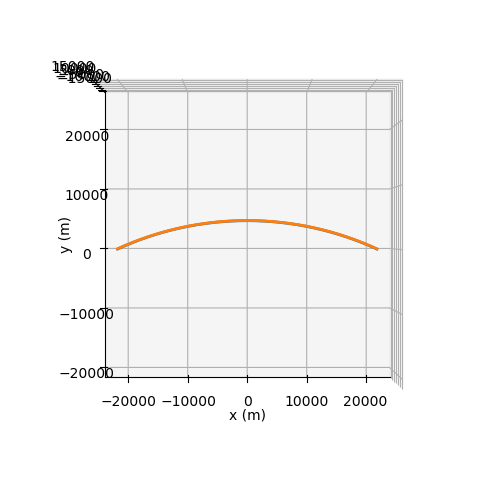

In [41]:
TunRad = 50000 #m
TunAng = (114.65, 65.35) #deg
node_spacing = 54.0  # desired spacing along the tunnel arc [m]

angle_start = np.deg2rad(TunAng[0])
angle_end = np.deg2rad(TunAng[1])
angle_step = node_spacing / TunRad
angles = np.arange(angle_start, angle_end - angle_step, -angle_step)

TunCX = TunRad*np.cos(angles)
TunCY = TunRad*np.sin(angles)
TunCZ = np.zeros_like(TunCX)

# Make the outer tunnel at a larger radius, so connectors become radial and perpendicular to the tunnel curve.
outerOffset = 30
TunRad2 = TunRad + outerOffset
TunCX2 = TunRad2*np.cos(angles)
TunCY2 = TunRad2*np.sin(angles)
TunCZ2 = np.zeros_like(TunCX2)

# Shift both curves together so the full tunnel pair is positioned above the x-axis
shiftY = -min(np.concatenate([TunCY, TunCY2])) + 5
TunCY += shiftY
TunCY2 += shiftY

ax = plt.axes(projection='3d')
ax.view_init(90, 270)
plt.plot(TunCX, TunCY, TunCZ, lw=2)
plt.plot(TunCX2, TunCY2, TunCZ2, lw=2)
plt.grid("on")
plt.axis("equal")
plt.xlabel('x (m)')
plt.ylabel('y (m)')

TunCX = np.append(TunCX, TunCX2)
TunCY = np.append(TunCY, TunCY2)
TunCZ = np.append(TunCZ, TunCZ2)

## Properties of Beam

In [42]:
E = 36.0e9            
nu = 0.2      
rho_w = 1025
rho_c = 2650
g = 9.81
#tunnel
D_out = 20 #m  
D_in = 18 #m
dist_c2c = 30.0 #m
A_beton = (np.pi / 4) * (D_out**2 - D_in**2)
I_beam = (np.pi / 64) * (D_out**4 - D_in**4) 

#connectie
D_out_conn = 6.0; D_in_conn = 5.0; L_conn = 10.0
A_beton_conn = (np.pi / 4) * (D_out_conn**2 - D_in_conn**2)
I_beton_conn = (np.pi / 64) * (D_out_conn**4 - D_in_conn**4)


In [43]:
Beam_m =  A_beton * rho_c + 749.0e3 / g               # [kg/m]
Beam_EI = E * I_beam               # [N.m2]
Beam_EA = E * A_beton              # [N]
Beam_G = E / (2 * (1 + nu))
Beam_J = 0.623 * ((D_out /2) ** 4)
Beam_GJ = Beam_G * Beam_J            # [N.m2]
Beam_Im = rho_c * Beam_J          #[kg.m]

In [44]:
conn_m = A_beton_conn * rho_c         
conn_EI = E * I_beton_conn
conn_EA = E * A_beton_conn

conn_G = E / (2 * (1 + nu))
conn_J = 0.623 * ((D_out_conn / 2) ** 4)
conn_GJ = conn_G * conn_J            
conn_Im = rho_c * conn_J

## Mesh setup

In [45]:
# =============================================================================
# CELL 9: ELEMENT DEFINITION TABLE (WITH YOUR VARIATING BALLAST PROFLE & ADDED MASS)
# =============================================================================

NodeC = [ [x,y,z] for x,y,z in zip(TunCX, TunCY, TunCZ) ]
nNode = len(NodeC)
nNodeTunnel = int(nNode/2)

def get_total_tube_mass_per_meter(node_index):
  
    x_pos_meter = node_index * node_spacing
    x_km = x_pos_meter / 1000.0
    
    if 0.0 <= x_km < 8.0: 
        F_ballast = 2425.33
    elif 8.0 <= x_km < 23.0: 
        F_ballast = 2408.77
    elif 23.0 <= x_km < 28.0: 
        F_ballast = 2352.75
    elif 28.0 <= x_km < 38.0: 
        F_ballast = 2405.78
    else: 
        F_ballast = 2424.70
        
    m_ballast = (F_ballast * 1000.0) / g
    
    A_buiten = (np.pi / 4) * (D_out**2)
    C_a_theory = 1.0
    added_mass_tube = rho_w * A_buiten * C_a_theory
    
    m_tot_meter = (A_beton * rho_c) + ((749.0e3 / g) / 2) + (m_ballast / 2) + added_mass_tube
    return m_tot_meter

def vind_lokale_mooring_stijfheid(x_pos_meter):

    x_km = x_pos_meter / 1000.0
    
    # ------------------------------------------------------------------
    # VUL HIERONDER DE EXACTE GETALLEN EN HOOGTES/DIEPTES UIT JE VERSLAG IN
    # (Dit is een voorbeeldopzet gebaseerd op de segmenten van de ballast)
    # ------------------------------------------------------------------
    if 0.0 <= x_km < 8.0:
        # Ondiep segment nabij de linkeroever
        Kxx = 1000 # Kyy uit rapport
        Kyy = 3169000  # Pas deze aan naar de waarde uit je tabel (N/m)
        Kzz = 2788000 # Pas deze aan naar de waarde uit je tabel (N/m)
        # Coupling terms (cross-stiffness from catenary/cable interaction)
        Kxy = 0
        Kxz = 0
        Kyz = 329000
        
    elif 8.0 <= x_km < 23.0:
        # Dieper segment (bijv. richting het midden, 250m waterdiepte)
        Kxx = 4370
        Kyy = 287000 
        Kzz = 31440 
        # Coupling terms
        Kxy = 0
        Kxz = 0
        Kyz = 64700
        
    elif 23.0 <= x_km < 28.0:
        Kxx = 8500
        Kyy = 290000
        Kzz = 35400
        # Coupling terms
        Kxy = 0
        Kxz = 0
        Kyz = 31700
        
    elif 28.0 <= x_km < 38.0:
        Kxx = 5000
        Kyy = 253000
        Kzz = 38500
        # Coupling terms
        Kxy = 0
        Kxz = 0
        Kyz = 45700
        
    else:
        # Ondiep segment nabij de rechteroever
        Kxx = 1000
        Kyy = 4682000
        Kzz = 4139000
        # Coupling terms
        Kxy = 0
        Kxz = 0
        Kyz = 633000
        
    return Kxx, Kyy, Kzz, Kxy, Kxz, Kyz 



In [46]:
Ele = []

# 1. Elementen voor Koker 1 (Binnenboog)
for i in range(0, nNodeTunnel - 1):
    m_dynamisch = get_total_tube_mass_per_meter(2*i)
    Ele.append([int(i), int(i + 1), m_dynamisch, Beam_EA, Beam_EI, Beam_GJ, Beam_Im])

# 2. Elementen voor Koker 2 (Buitenboog)
for i in range(0, nNodeTunnel - 1):
    n1 = i + nNodeTunnel
    n2 = n1 + 1
    m_dynamisch = get_total_tube_mass_per_meter(2*i)
    Ele.append([int(n1), int(n2), m_dynamisch, Beam_EA, Beam_EI, Beam_GJ, Beam_Im])

# 3. Connectoren (Nooduitgangen / Cross-passages) tussen Koker 1 en Koker 2
connector_interval = 8
for i in range(0, nNodeTunnel, connector_interval):
    n1 = i
    n2 = i + nNodeTunnel
    # Zorg dat we niet buiten de totale hoeveelheid knopen (nNode) schieten
    if n2 < nNode:
        Ele.append([int(n1), int(n2), conn_m, conn_EA, conn_EI, conn_GJ, conn_Im])

# Converteer naar een standaard Python lijst van lijsten (of float array), 
# maar we updaten direct nEle!
nEle = len(Ele)

print(f"Totaal aantal knopen (nNode): {nNode}")
print(f"Totaal aantal elementen (nEle) inclusief connectoren: {nEle}")
# Check 1: Komen er connectoren voor in de lijst?
connectoren_gevonden = 0
for el in Ele:
    # Als het verschil tussen knoop 2 en knoop 1 gelijk is aan nNodeTunnel, is het een connector
    if int(round(el[1])) - int(round(el[0])) == nNodeTunnel:
        connectoren_gevonden += 1

print(f"Aantal actieve connectoren in de elementenlijst: {connectoren_gevonden}")

Totaal aantal knopen (nNode): 1596
Totaal aantal elementen (nEle) inclusief connectoren: 1694
Aantal actieve connectoren in de elementenlijst: 100


Listing the nodes and elements. <br>
Plot the mesh setup for reference.

Nodes
Elements


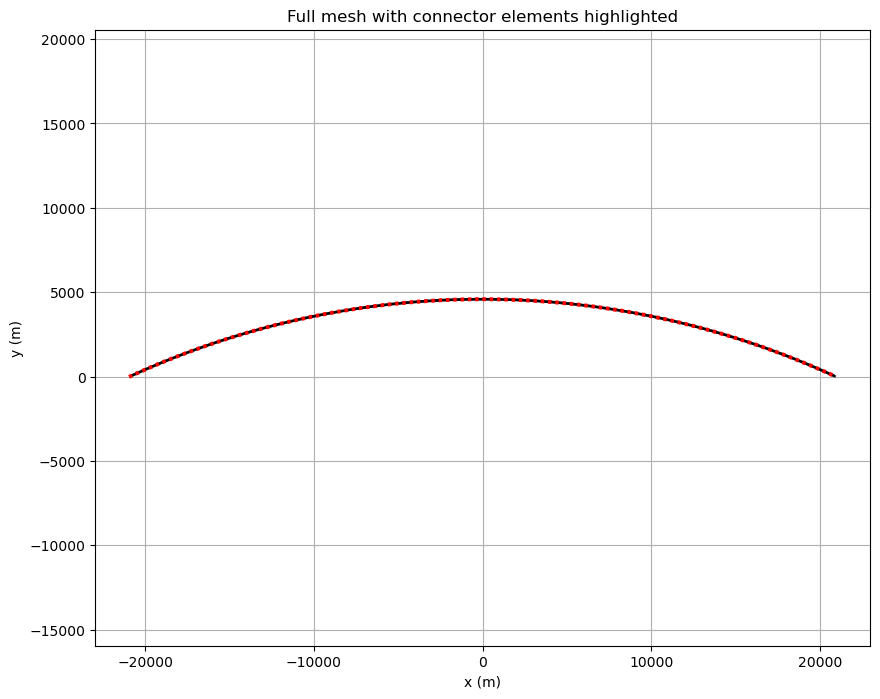

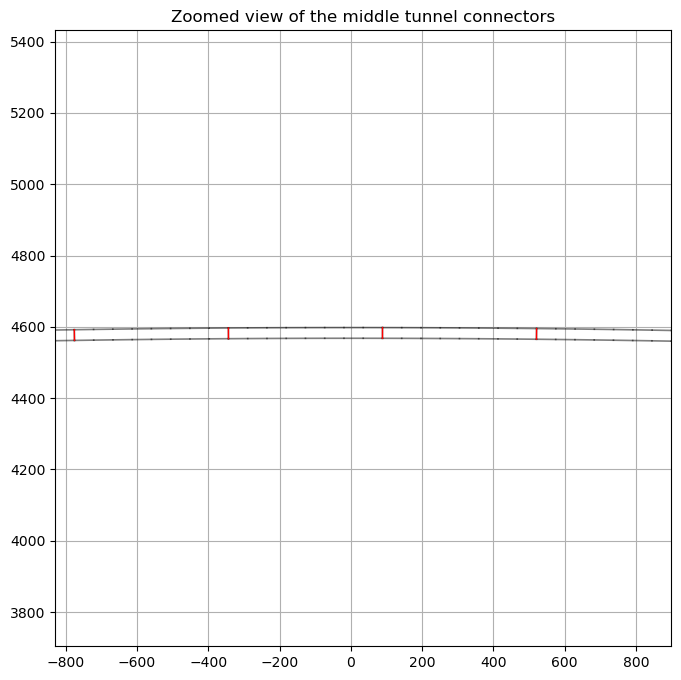

In [47]:
print("Nodes")
# for iNode in range(0, nNode):
#     print(iNode, "\t", NodeC[iNode][0], "\t", NodeC[iNode][1], "\t", NodeC[iNode][2])

NodeC_arr = np.array(NodeC)

plt.figure(figsize=(10, 8))
print("Elements")
for iEle in range(0, nEle):
    n1, n2, m, EA, EI, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    plt.plot([NodeC[n1][0], NodeC[n2][0]],
             [NodeC[n1][1], NodeC[n2][1]],
             lw=1.5, color='k', alpha=0.5)

for iEle in range(0, nEle):
    n1, n2, m, EA, EI, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    if abs(n2 - n1) > 1: # Filter die de cross-passages herkent
        plt.plot([NodeC_arr[n1,0], NodeC_arr[n2,0]],
                 [NodeC_arr[n1,1], NodeC_arr[n2,1]],
                 lw=2.5, color='red')

plt.grid(True)
plt.axis('equal')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Full mesh with connector elements highlighted')

# Zoom into the middle section for better visibility
center_index = nNodeTunnel // 2
x_center = NodeC_arr[center_index, 0]
y_center = NodeC_arr[center_index, 1]
span = 1000

fig, ax = plt.subplots(figsize=(10, 8))

for iEle in range(0, nEle):
    n1, n2, m, EA, EI, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    ax.plot([NodeC[n1][0], NodeC[n2][0]],
            [NodeC[n1][1], NodeC[n2][1]],
            lw=1.2, color='k', alpha=0.5)

# Plot de rode connectors
for iEle in range(0, nEle):
    n1, n2, m, EA, EI, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    if abs(n2 - n1) > 1:
        ax.plot([NodeC_arr[n1,0], NodeC_arr[n2,0]],
                [NodeC_arr[n1,1], NodeC_arr[n2,1]],
                lw=1, color='red')

# Zoom instellen
span = 864 # (16 nodes * 54m)
ax.set_xlim(x_center - span, x_center + span)
ax.set_ylim(y_center - span, y_center + span)

# Gebruik aspect='equal' in plaats van plt.axis('equal')
ax.set_aspect('equal')
ax.grid(True)
ax.set_title('Zoomed view of the middle tunnel connectors')
pass

## Define the shape functions

Here we will use **linear** shape functions for the **axial displacement** and **cubic** shape functions for the **deflection and rotations**. Since we already know its expression and we already have the value of the elemental matrices, we skip this step in this tutorial. 

## Computation of the elemental matrices

In the theory we have seen that the mass and stiffness elemental matrices for the space frame using linear and cubic shape functions are given by:

| <img width="50%" src="./img/nb09_f01_3Ddofs_nptel.png" /> |
| :---- |
| Fig 1: Definition of 3 dofs per node, for the 2 noded elements. (This is from my lectures slides. To Be replaced) |

$$ M = \frac{mL}{420} 
\begin{bmatrix} 
140 & 0 & 0 & 0 & 0 & 0 & 70 & 0 & 0 & 0 & 0 & 0 \\ 
0 & 156 & 0 & 0 & 0 & 22L & 0 & 54 & 0 & 0 & 0 & -13L \\ 
0 & 0 & 156 & 0 & 22L & 0 & 0 & 0 & 54 & 0 & 13L & 0 \\ 
0 & 0 & 0 & 140 & 0 & 0 & 0 & 0 & 0 & 70 & 0 & 0 \\ 
0 & 0 & 22L & 0 & 4L^2 & 0 & 0 & 0 & -13L & 0 & -3L^2 & 0 \\ 
0 & 22L & 0 & 0 & 0 & 4L^2 & 0 & 13L & 0 & 0 & 0 & -3L^2 \\ 
70 & 0 & 0 & 0 & 0 & 0 & 140 & 0 & 0 & 0 & 0 & 0 \\ 
0 & 54 & 0 & 0 & 0 & 13L & 0 & 156 & 0 & 0 & 0 & -22L \\ 
0 & 0 & 54 & 0 & -13L & 0 & 0 & 0 & 156 & 0 & 22L & 0 \\ 
0 & 0 & 0 & 70 & 0 & 0 & 0 & 0 & 0 & 140 & 0 & 0 \\ 
0 & 0 & 13L & 0 & -3L^2 & 0 & 0 & 0 & 22L & 0 & 4L^2 & 0 \\
0 & -13L & 0 & 0 & 0 & -3L^2 & 0 & -22L & 0 & 0 & 0 & 4L^2
\end{bmatrix} $$
$$ \quad K = 
\begin{bmatrix} 
\frac{EA}{L} & 0 & 0 & 0 & 0 & 0 & \frac{-EA}{L} &  0 & 0 & 0 & 0 & 0\\ 
0 & \frac{12EI}{L^3} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{-12EI}{L^3} & 0 & 0 & 0 & \frac{6EI}{L^2} \\ 
0 & 0 & \frac{12EI}{L^3} & 0 & -\frac{6EI}{L^2} & 0 & 0 & 0 & \frac{-12EI}{L^3} & 0 & -\frac{6EI}{L^2} & 0\\ 
0 & 0 & 0 & \frac{GJ}{L} & 0 & 0 & 0 & 0 & 0 & -\frac{GJ}{L} & 0 & 0 \\ 
0 & 0 & \frac{-6EI}{L^2} & 0 & \frac{4EI}{L} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{2EI}{L} & 0 \\ 
0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{4EI}{L} & 0 & \frac{-6EI}{L^2} & 0 & 0 & 0 & \frac{2EI}{L} \\ 
\frac{-EA}{L} & 0 & 0 & 0 & 0 & 0 & \frac{EA}{L} & 0 & 0 & 0 & 0 & 0 \\ 
0 & -\frac{12EI}{L^3} & 0 & 0 & 0 & -\frac{6EI}{L^2} & 0 & \frac{12EI}{L^3} & 0 & 0 & 0 & -\frac{6EI}{L^2} \\ 
0 & 0 & -\frac{12EI}{L^3} & 0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{12EI}{L^3} & 0 & \frac{6EI}{L^2} & 0\\ 
0 & 0 & 0 & -\frac{GJ}{L} & 0 & 0 & 0 & 0 & 0 & \frac{GJ}{L} & 0 & 0 \\ 
0 & 0 & -\frac{6EI}{L^2} & 0 & \frac{2EI}{L} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{4EI}{L} & 0 \\ 
0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{2EI}{L} & 0 & -\frac{6EI}{L^2} & 0 & 0 & 0 & \frac{4EI}{L}
\end{bmatrix}$$

These matrices are used directly when calling the `BeamMatrices` function within the assembly process.

## Global assembly

The last step is to compute the global matrices and the global forcing vector. We start by initializing the global matrices as 1-dimensional arrays.

Then we loop over elements and perform all the elemental operations.

In [48]:
import time
import numpy as np
from BeamMatrices import Beam3DMatrices

LDOF = 6
nDof = LDOF * nNode  # 6 dof per node

# Initialiseer de matrices direct als echte 2D-vlakken van (nDof, nDof)
# Dit elimineert de kans op een verticale lijn door foute 1D-reshapes!
K = np.zeros(nDof * nDof)
M = np.zeros(nDof * nDof)
Q = np.zeros(nDof * nDof)

exeTime = [0.0, 0.0]
exeTime[0] = time.time()

# 1. LOOP OVER ALLE ELEMENTEN (TUNNELKOKERS + EB-TUSSENSTUKKEN)
for iEle in range(0, nEle):
    n1 = int(round(Ele[iEle][0]))
    n2 = int(round(Ele[iEle][1]))
    
    n1dof = LDOF * n1 + np.arange(0, LDOF)
    n2dof = LDOF * n2 + np.arange(0, LDOF)    
    indexes = np.append(n1dof, n2dof)
    
   
    Me, Ke, Qe = Beam3DMatrices(Ele[iEle][2], Ele[iEle][3], Ele[iEle][4], Ele[iEle][5], Ele[iEle][6], (NodeC[n1], NodeC[n2]))
    
    # --- Authentieke fix voor de rotatie van de tussenstukken (Cross-passages) ---
    if (n2 - n1) == nNodeTunnel:  # Dit is een cross-passage element
        dx = NodeC[n2][0] - NodeC[n1][0]
        dy = NodeC[n2][1] - NodeC[n1][1]
        L = np.sqrt(dx**2 + dy**2)
        
        cx = dx / L
        cy = dy / L
        
        T_corr = np.array([[-cy, cx, 0], 
                           [-cx, -cy, 0], 
                           [0, 0, 1]])
        
        T_element = np.zeros((12, 12))
        for i_block in range(4):
            T_element[i_block*3:(i_block+1)*3, i_block*3:(i_block+1)*3] = T_corr
            
        Ke = T_element.T @ Ke @ T_element
        Me = T_element.T @ Me @ T_element
        Qe = T_element.T @ Qe @ T_element

    # Jouw originele inbeddings-loop via 1D array indexering 'ij'
    for i in range(0, 2 * LDOF):
        for j in range(0, 2 * LDOF):
            ij = indexes[i] * nDof + indexes[j]
            M[ij] = M[ij] + Me[i, j]
            K[ij] = K[ij] + Ke[i, j]
            Q[ij] = Q[ij] + Qe[i, j]

# Reshapen naar de benodigde 2D matrices voor de randvoorwaarden en solver
M = M.reshape((nDof, nDof))
K = K.reshape((nDof, nDof))
Q = Q.reshape((nDof, nDof))

for i in range(0, nNodeTunnel):
    # --- KOKER 1 (Binnenboog) ---
    x_pos_k1 = i * node_spacing  
    Kxx_k1, Kyy_k1, Kzz_k1, Kxy_k1, Kxz_k1, Kyz_k1 = vind_lokale_mooring_stijfheid(x_pos_k1)
    
    dof_x_k1 = i * LDOF + 0  # Axiaal (X)
    dof_y_k1 = i * LDOF + 1  # Transversaal (Y)
    dof_z_k1 = i * LDOF + 2  # Verticaal (Z)
    
    # Diagonal terms
    K[dof_x_k1, dof_x_k1] += Kxx_k1
    K[dof_y_k1, dof_y_k1] += Kyy_k1
    K[dof_z_k1, dof_z_k1] += Kzz_k1
    
    # Off-diagonal coupling terms (symmetric pairs)
    K[dof_x_k1, dof_y_k1] += Kxy_k1
    K[dof_y_k1, dof_x_k1] += Kxy_k1
    K[dof_x_k1, dof_z_k1] += Kxz_k1
    K[dof_z_k1, dof_x_k1] += Kxz_k1
    K[dof_y_k1, dof_z_k1] += Kyz_k1
    K[dof_z_k1, dof_y_k1] += Kyz_k1
    
    # --- KOKER 2 (Buitenboog) ---
    n_k2 = i 
    x_pos_k2 = NodeC[n_k2][0]
    Kxx_k2, Kyy_k2, Kzz_k2, Kxy_k2, Kxz_k2, Kyz_k2 = vind_lokale_mooring_stijfheid(x_pos_k1)
    
    dof_x_k2 = n_k2 * LDOF + 0  # Axiaal (X)
    dof_y_k2 = n_k2 * LDOF + 1  # Transversaal (Y)
    dof_z_k2 = n_k2 * LDOF + 2  # Verticaal (Z)
    
    # Diagonal terms
    K[dof_x_k2, dof_x_k2] += Kxx_k2
    K[dof_y_k2, dof_y_k2] += Kyy_k2
    K[dof_z_k2, dof_z_k2] += Kzz_k2
    
    # Off-diagonal coupling terms (symmetric pairs)
    K[dof_x_k2, dof_y_k2] += Kxy_k2
    K[dof_y_k2, dof_x_k2] += Kxy_k2
    K[dof_x_k2, dof_z_k2] += Kxz_k2
    K[dof_z_k2, dof_x_k2] += Kxz_k2
    K[dof_y_k2, dof_z_k2] += Kyz_k2
    K[dof_z_k2, dof_y_k2] += Kyz_k2

exeTime[1] = time.time()
print("Handmatige assemblage succesvol voltooid!")
print("Execution time = {:.4f} s".format(exeTime[1] - exeTime[0]))

Handmatige assemblage succesvol voltooid!
Execution time = 0.9732 s


That completes the filling of the matrices. Let's have a look at the matrices' structure.

In [49]:
# Look at the matrix structure
plt.figure()
#### 

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

## Boundary conditions

To apply the boundary conditions, we will remove the rows associated to the fixed DOFs and add the contribution to the right-hand-side. First, we obtain the free and fixed DOFs.

[   0    1    2    3    4    5 4782 4783 4784 4785 4786 4787 4788 4789
 4790 4791 4792 4793 9570 9571 9572 9573 9574 9575]
[   6    7    8 ... 9567 9568 9569]


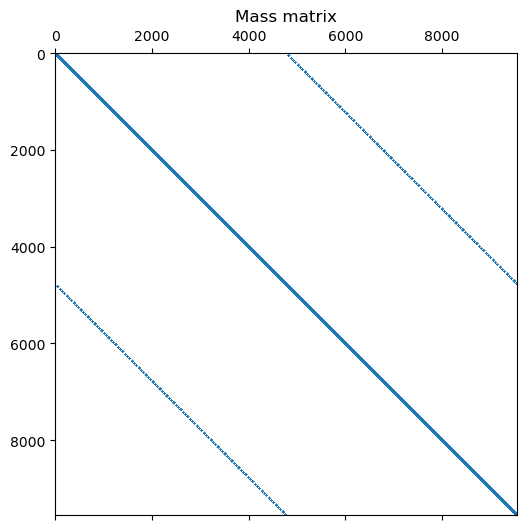

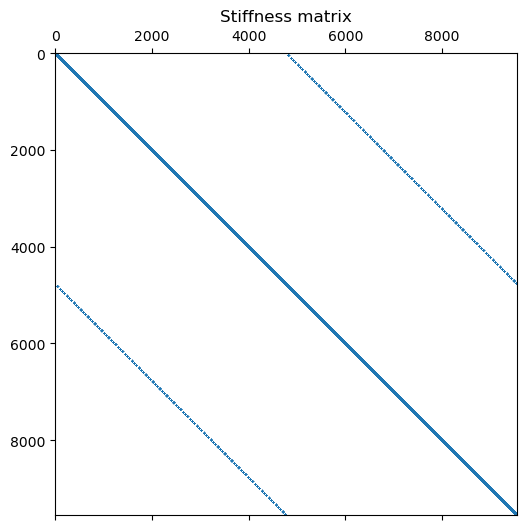

In [50]:
NodesClamp = (0, int(round(nNode/2-1)), int(round(nNode/2)), nNode-1)

# Prescribed dofs
DofsP = np.empty([0], dtype=int)
for n0 in NodesClamp:
    DofsP = np.append(DofsP, n0*LDOF + np.arange(0,LDOF))

# Free dofs
DofsF = np.arange(0, nDof)       # free DOFs
DofsF = np.delete(DofsF, DofsP)  # remove the fixed DOFs from the free DOFs array

print(DofsP)
print(DofsF)

M_FF = [ M[iRow,DofsF].tolist() for iRow in DofsF ]
K_FF = [ K[iRow,DofsF].tolist() for iRow in DofsF ]
Q_FF = [ Q[iRow,DofsF].tolist() for iRow in DofsF ]

plt.figure()
plt.spy(M_FF, markersize=0.2)
plt.title("Mass matrix")
plt.figure()
plt.spy(K_FF, markersize=0.2)
plt.title("Stiffness matrix")
pass

## Modal analysis

Using the matrices associated to the free DOFs, we can perform a modal analysis to get more information on how the structure will deform and determine the natural frequencies.

$$ ( K_{FF} - \omega^2 M_{FF} ) \phi = 0 $$

To compute the natural frequencies and mode shapes we use the `eig` command, which is part of the NumPy package. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html

In [51]:
mat = np.dot(np.linalg.inv(M_FF), K_FF)
w2, vr = np.linalg.eig(mat)
w = np.sqrt(w2.real)
f = w/2/np.pi
print(len(f))

9552


C:\Users\boris\AppData\Local\Temp\ipykernel_22908\367166604.py:3: RuntimeWarning: invalid value encountered in sqrt
  w = np.sqrt(w2.real)


In [52]:
idx = f.argsort()
f = f[idx]
vr = vr[:,idx]

print(f)

[3.58848167e-05 6.97410183e-05 1.04028029e-04 ...            nan
            nan            nan]


In [53]:
nMode = len(f)
print(nMode)
ModalShape = np.zeros((nDof, nMode))
ModalShape[DofsF,:] = vr

9552


In [54]:
# # Plotting mode shapes
# plt.figure()
# cmap = plt.colormaps.get_cmap('Accent')
# cmap = cmap.colors
# nCmap = len(cmap)

# nCol = 2
# nRow = int(np.floor(nMode/nCol))+1

# vMode1 = 9
# vMode2 = vMode1+18

# def plotEle(DisplacedNode):
#     for iElem in np.arange(0, nEle):
#         NodeLeft = int(round(Ele[iElem][0]))
#         NodeRight = int(round(Ele[iElem][1]))
#         if(iElem == 0):
#             plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
#                      [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], color=cmap[iMode%nCmap], 
#                      label = "Mode "+str(iMode)+": f = "+str(np.round(f[iMode],6))+" Hz")
#         else:
#             plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
#                      [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], color=cmap[iMode%nCmap])


# # XY Plot
# for iMode in np.arange(vMode1, vMode2):    
#     Shape = ModalShape[:, iMode]

#     # Scale the mode such that maximum deformation is 10
#     MaxTranslationx = np.max(np.abs(Shape[0::LDOF]))
#     MaxTranslationy = np.max(np.abs(Shape[1::LDOF]))
#     MaxTranslationz = np.max(np.abs(Shape[2::LDOF]))
#     Shape[0::LDOF] = Shape[0::LDOF]/MaxTranslationx*100
#     Shape[1::LDOF] = Shape[1::LDOF]/MaxTranslationy*100
#     Shape[2::LDOF] = Shape[2::LDOF]/MaxTranslationz*100    

#     # Get the deformed shape
#     DisplacedNode = ([i[0] + (iMode%3-1)*4000 for i in NodeC] + Shape[0::LDOF], 
#                      [i[1] + 300*np.floor(iMode/3) for i in NodeC] + Shape[1::LDOF])
    
#     plotEle(DisplacedNode)
#     plt.title("XY Plot")        
#     plt.grid('on')
#     plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3),
#           ncol=4, fancybox=True, shadow=True)    


# # XZ Plot
# plt.figure()
# for iMode in np.arange(vMode1, vMode2):    
#     Shape = ModalShape[:, iMode]

#     # Scale the mode such that maximum deformation is 10
#     MaxTranslationx = np.max(np.abs(Shape[0::LDOF]))
#     MaxTranslationy = np.max(np.abs(Shape[1::LDOF]))
#     MaxTranslationz = np.max(np.abs(Shape[2::LDOF]))
#     Shape[0::LDOF] = Shape[0::LDOF]/MaxTranslationx*100
#     Shape[1::LDOF] = Shape[1::LDOF]/MaxTranslationy*100
#     Shape[2::LDOF] = Shape[2::LDOF]/MaxTranslationz*100

#     # Get the deformed shape
#     DisplacedNode = ([i[0] + (iMode%3-1)*4000 for i in NodeC] + Shape[0::LDOF],
#                      [i[2] + np.floor(iMode/3)*300 for i in NodeC] + Shape[2::LDOF])
    
#     plotEle(DisplacedNode)
#     plt.title("XZ Plot")    
#     plt.grid('on')
#     plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3),
#           ncol=4, fancybox=True, shadow=True)    
    


# pass

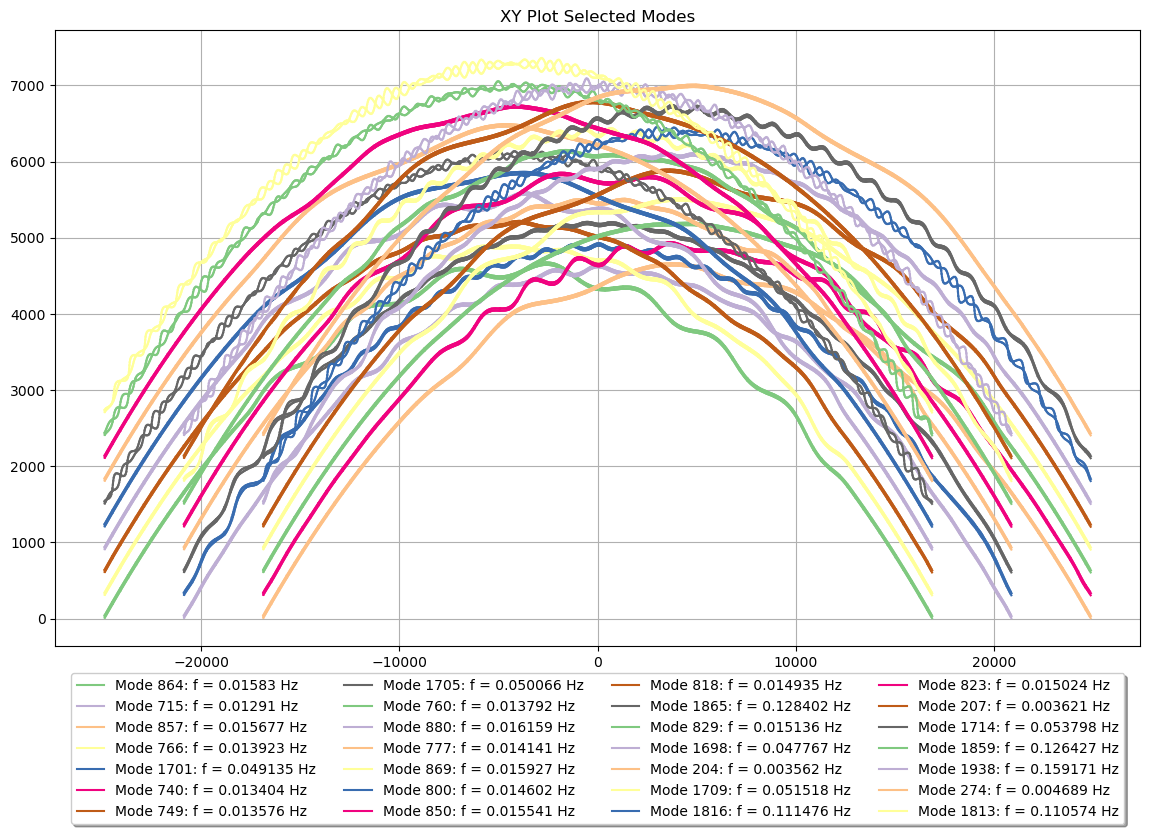

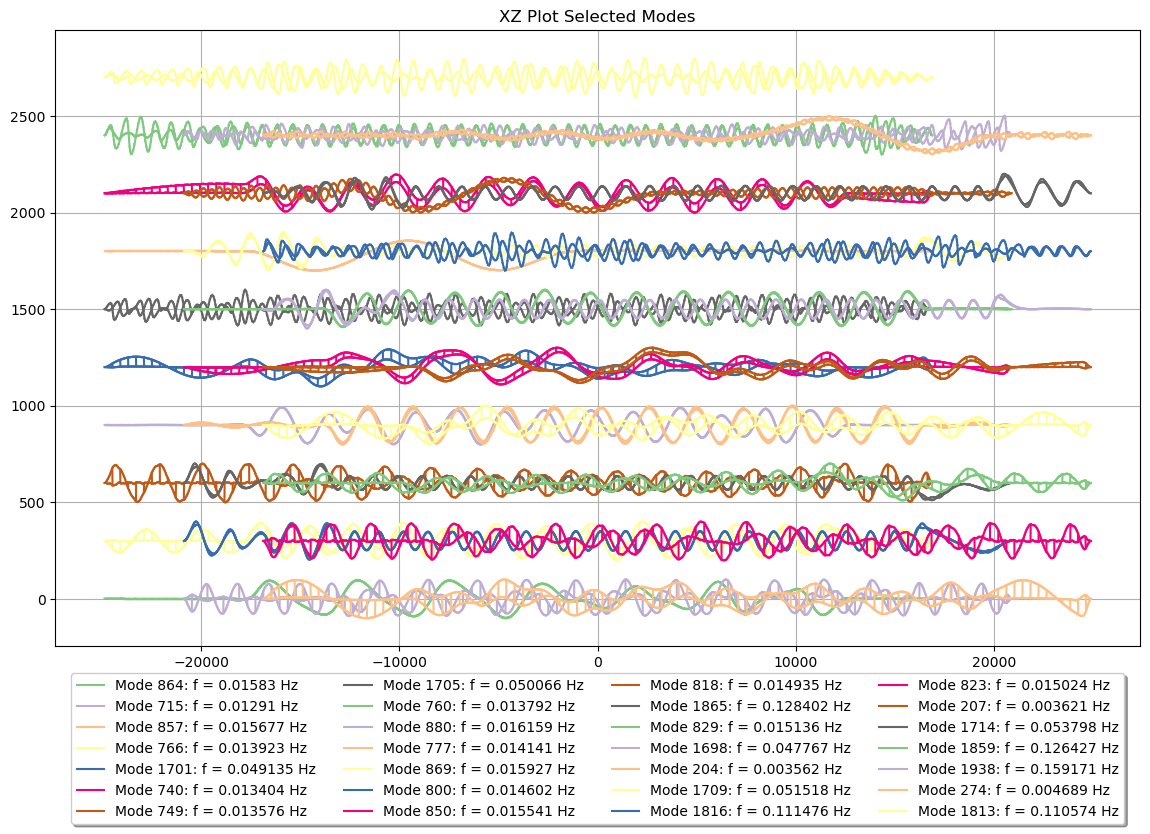

In [55]:
import numpy as np
import matplotlib.pyplot as plt

important_modes = [864, 715, 857, 766, 1701, 740, 749, 1705, 760, 880, 777, 869, 800, 850, 818, 1865, 829, 1698, 204, 1709, 1816, 823, 207, 1714, 1859, 1938, 274, 1813]

plt.figure(figsize=(14, 8))
cmap = plt.colormaps.get_cmap('Accent')
cmap = cmap.colors
nCmap = len(cmap)

# We geven idx en iMode mee aan de functie zodat de kleuren en labels correct blijven
def plotEle(DisplacedNode, idx, iMode):
    for iElem in np.arange(0, nEle):
        NodeLeft = int(round(Ele[iElem][0]))
        NodeRight = int(round(Ele[iElem][1]))
        if(iElem == 0):
            plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
                     [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], color=cmap[idx % nCmap], 
                     label = "Mode "+str(iMode)+": f = "+str(np.round(f[iMode],6))+" Hz")
        else:
            plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
                     [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], color=cmap[idx % nCmap])

# XY Plot
# Gebruik enumerate om de teller (idx) en het modenummer (iMode) te krijgen
for idx, iMode in enumerate(important_modes):    
    Shape = ModalShape[:, iMode]

    # Scale the mode such that maximum deformation is 100
    MaxTranslationx = np.max(np.abs(Shape[0::LDOF]))
    MaxTranslationy = np.max(np.abs(Shape[1::LDOF]))
    MaxTranslationz = np.max(np.abs(Shape[2::LDOF]))
    
    # Veiligheidscheck ingebouwd om delen door 0 te voorkomen
    if MaxTranslationx > 0: Shape[0::LDOF] = Shape[0::LDOF]/MaxTranslationx*100
    if MaxTranslationy > 0: Shape[1::LDOF] = Shape[1::LDOF]/MaxTranslationy*100
    if MaxTranslationz > 0: Shape[2::LDOF] = Shape[2::LDOF]/MaxTranslationz*100    

    # Get the deformed shape (Let op: offset nu gebaseerd op 'idx', niet op 'iMode')
    DisplacedNode = ([i[0] + (idx%3-1)*4000 for i in NodeC] + Shape[0::LDOF], 
                     [i[1] + 300*np.floor(idx/3) for i in NodeC] + Shape[1::LDOF])
    
    plotEle(DisplacedNode, idx, iMode)

plt.title("XY Plot Selected Modes")        
plt.grid(True)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=4, fancybox=True, shadow=True)    


# XZ Plot
plt.figure(figsize=(14, 8))
for idx, iMode in enumerate(important_modes):    
    Shape = ModalShape[:, iMode]

    # Scale the mode such that maximum deformation is 100
    MaxTranslationx = np.max(np.abs(Shape[0::LDOF]))
    MaxTranslationy = np.max(np.abs(Shape[1::LDOF]))
    MaxTranslationz = np.max(np.abs(Shape[2::LDOF]))
    
    if MaxTranslationx > 0: Shape[0::LDOF] = Shape[0::LDOF]/MaxTranslationx*100
    if MaxTranslationy > 0: Shape[1::LDOF] = Shape[1::LDOF]/MaxTranslationy*100
    if MaxTranslationz > 0: Shape[2::LDOF] = Shape[2::LDOF]/MaxTranslationz*100

    # Get the deformed shape (offset op basis van 'idx')
    DisplacedNode = ([i[0] + (idx%3-1)*4000 for i in NodeC] + Shape[0::LDOF],
                     [i[2] + np.floor(idx/3)*300 for i in NodeC] + Shape[2::LDOF])
    
    plotEle(DisplacedNode, idx, iMode)
    
plt.title("XZ Plot Selected Modes")    
plt.grid(True)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=4, fancybox=True, shadow=True)    

plt.show()

In [56]:
# # =========================================================
# # ZOOMED MODAL SHAPES - 40 MIDDLE NODES (INCLUDING CONNECTORS/EB BEAMS)
# # =========================================================

# # Define the 40 middle nodes (center ± 20) for each tunnel
# center_node = nNodeTunnel // 2  # Center node of each tunnel
# middle_40_tunnel1 = np.arange(center_node - 20, center_node + 20)
# # Include corresponding nodes from tunnel 2 (offset by nNodeTunnel)
# middle_40_tunnel2 = middle_40_tunnel1 + nNodeTunnel
# middle_40_nodes_all = np.concatenate([middle_40_tunnel1, middle_40_tunnel2])

# # Convert all middle nodes (both tunnels) to set for faster lookup
# middle_nodes_set = set(middle_40_nodes_all)

# def plotEle_Zoomed(DisplacedNode, middle_nodes_set):
#     """Plot only elements that connect nodes within the middle region (includes connectors/EB beams)"""
#     first_element = True
#     for iElem in np.arange(0, nEle):
#         NodeLeft = int(round(Ele[iElem][0]))
#         NodeRight = int(round(Ele[iElem][1]))
        
#         # Plot if at least one node is in the middle region (allows connectors to show)
#         if NodeLeft in middle_nodes_set or NodeRight in middle_nodes_set:
#             if first_element:
#                 plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
#                          [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], 
#                          color=cmap[iMode%nCmap], 
#                          label="Mode "+str(iMode)+": f = "+str(np.round(f[iMode],6))+" Hz",
#                          linewidth=2)
#                 first_element = False
#             else:
#                 plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
#                          [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], 
#                          color=cmap[iMode%nCmap],
#                          linewidth=2)

# # XY Plot - Zoomed
# plt.figure(figsize=(14, 10))
# for iMode in np.arange(vMode1, vMode2):    
#     Shape = ModalShape[:, iMode].copy()

#     # Scale the mode such that maximum deformation is 100
#     MaxTranslationx = np.max(np.abs(Shape[0::LDOF]))
#     MaxTranslationy = np.max(np.abs(Shape[1::LDOF]))
#     MaxTranslationz = np.max(np.abs(Shape[2::LDOF]))
#     Shape[0::LDOF] = Shape[0::LDOF]/MaxTranslationx*100
#     Shape[1::LDOF] = Shape[1::LDOF]/MaxTranslationy*100
#     Shape[2::LDOF] = Shape[2::LDOF]/MaxTranslationz*100    

#     # Get the deformed shape
#     DisplacedNode = ([i[0] + (iMode%3-1)*400 for i in NodeC] + Shape[0::LDOF], 
#                      [i[1] + 300*np.floor(iMode/3) for i in NodeC] + Shape[1::LDOF])
    
#     plotEle_Zoomed(DisplacedNode, middle_nodes_set)
    
# plt.title("XY Plot - 40 Middle Nodes + Connectors/EB Beams (Zoomed)", fontsize=14, fontweight='bold')        
# plt.grid('on', alpha=0.3)
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=6, fancybox=True, shadow=True)
# plt.tight_layout()

# # XZ Plot - Zoomed
# plt.figure(figsize=(14, 10))
# for iMode in np.arange(vMode1, vMode2):    
#     Shape = ModalShape[:, iMode].copy()

#     # Scale the mode such that maximum deformation is 100
#     MaxTranslationx = np.max(np.abs(Shape[0::LDOF]))
#     MaxTranslationy = np.max(np.abs(Shape[1::LDOF]))
#     MaxTranslationz = np.max(np.abs(Shape[2::LDOF]))
#     Shape[0::LDOF] = Shape[0::LDOF]/MaxTranslationx*100
#     Shape[1::LDOF] = Shape[1::LDOF]/MaxTranslationy*100
#     Shape[2::LDOF] = Shape[2::LDOF]/MaxTranslationz*100

#     # Get the deformed shape
#     DisplacedNode = ([i[0] + (iMode%3-1)*400 for i in NodeC],
#                      [i[2] + np.floor(iMode/3)*300 for i in NodeC] + Shape[2::LDOF])
    
#     plotEle_Zoomed(DisplacedNode, middle_nodes_set)
    
# plt.title("XZ Plot - 40 Middle Nodes + Connectors/EB Beams (Zoomed)", fontsize=14, fontweight='bold')    
# plt.grid('on', alpha=0.3)
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=6, fancybox=True, shadow=True)
# plt.tight_layout()

# print(f"Plotted modal shapes for 40 middle nodes from each tunnel + all connecting EB beams")
# print(f"Tunnel 1 nodes: {middle_40_tunnel1[0]} to {middle_40_tunnel1[-1]}")
# print(f"Tunnel 2 nodes: {middle_40_tunnel2[0]} to {middle_40_tunnel2[-1]}")
# print(f"Center node (per tunnel): {center_node}")

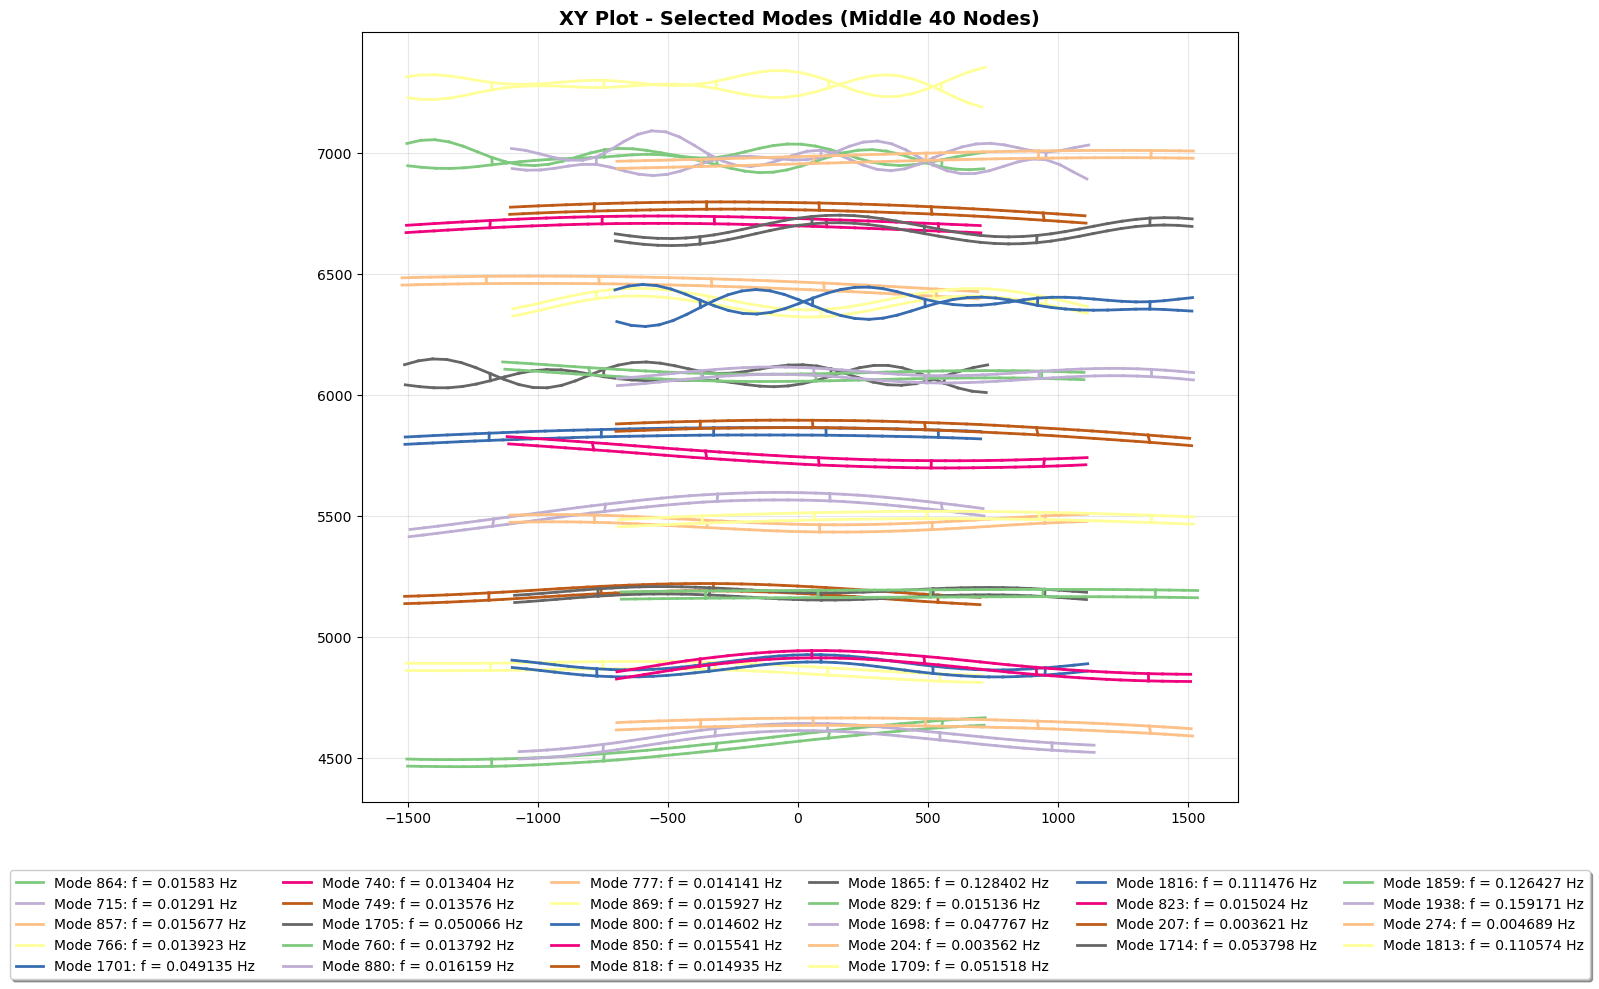

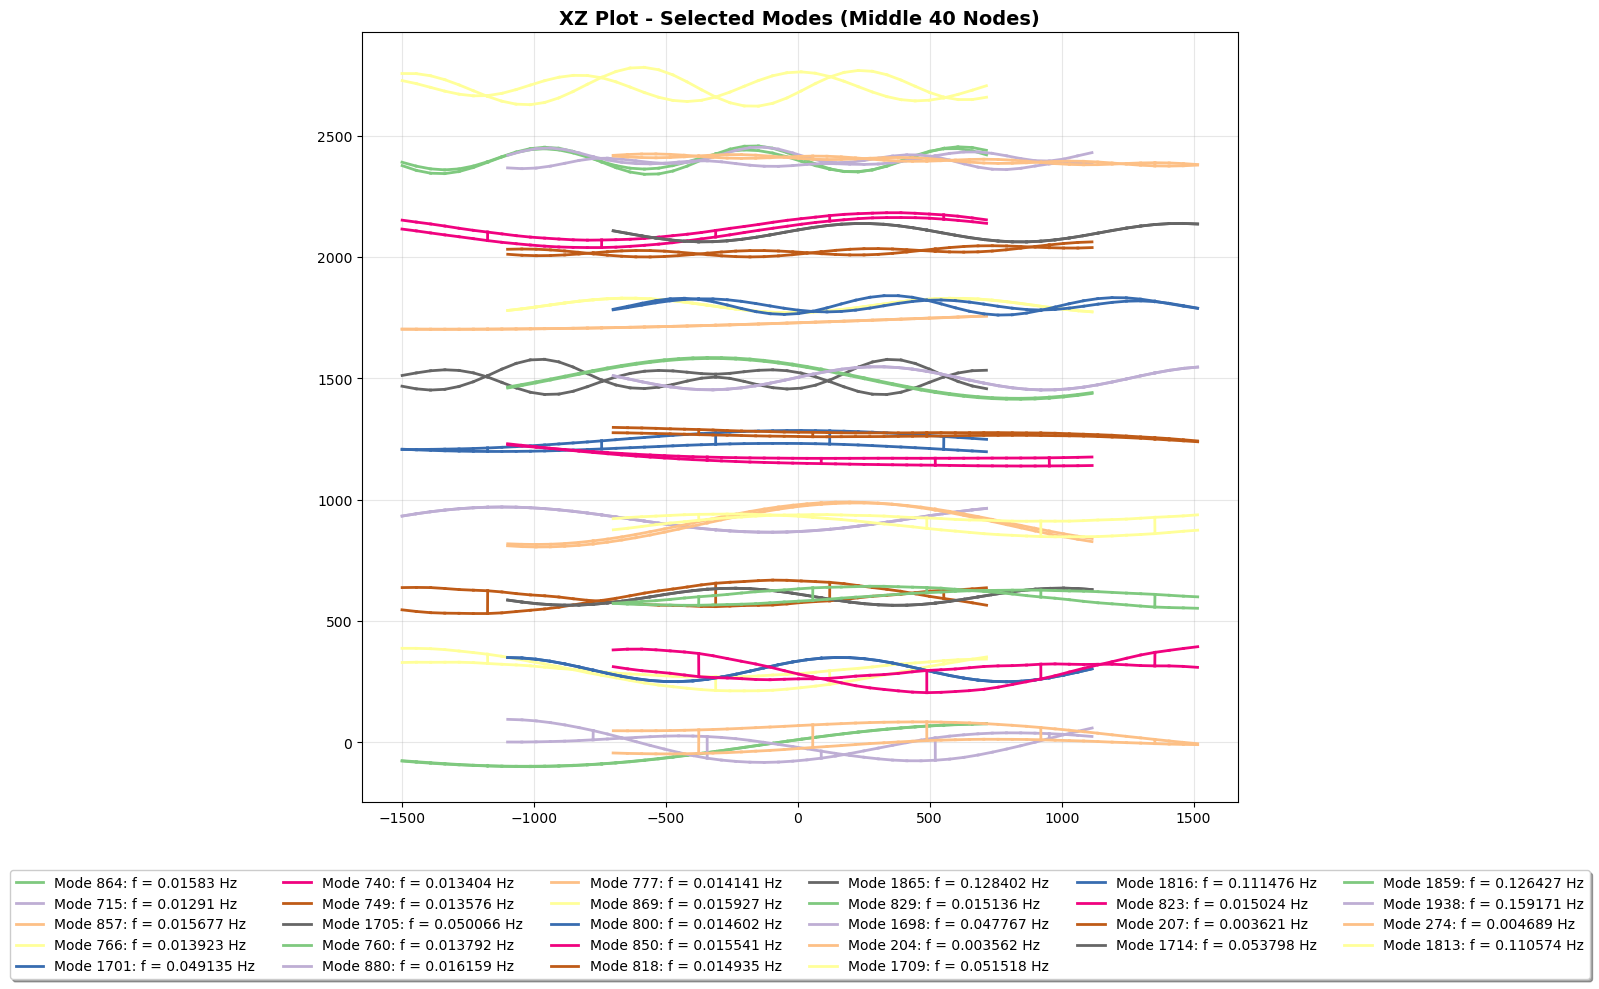

Plotted selected modal shapes (28 modes) for the middle 40 nodes of each tunnel + all connecting EB beams
Tunnel 1 nodes: 379 to 418
Tunnel 2 nodes: 1177 to 1216
Center node (per tunnel): 399


In [57]:
# =========================================================
# ZOOMED MODAL SHAPES - 40 MIDDLE NODES (INCLUDING CONNECTORS/EB BEAMS)
# =========================================================

# Define the 40 middle nodes (center ± 20) for each tunnel
center_node = nNodeTunnel // 2  # Center node of each tunnel
middle_40_tunnel1 = np.arange(center_node - 20, center_node + 20)
# Include corresponding nodes from tunnel 2 (offset by nNodeTunnel)
middle_40_tunnel2 = middle_40_tunnel1 + nNodeTunnel
middle_40_nodes_all = np.concatenate([middle_40_tunnel1, middle_40_tunnel2])

# Convert all middle nodes (both tunnels) to set for faster lookup
middle_nodes_set = set(middle_40_nodes_all)

# Pass idx and iMode to ensure correct colors and labels
def plotEle_Zoomed(DisplacedNode, middle_nodes_set, idx, iMode):
    """Plot only elements that connect nodes within the middle region (includes connectors/EB beams)"""
    first_element = True
    for iElem in np.arange(0, nEle):
        NodeLeft = int(round(Ele[iElem][0]))
        NodeRight = int(round(Ele[iElem][1]))
        
        # Plot if at least one node is in the middle region (allows connectors to show)
        if NodeLeft in middle_nodes_set or NodeRight in middle_nodes_set:
            if first_element:
                plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
                         [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], 
                         color=cmap[idx % nCmap], 
                         label="Mode "+str(iMode)+": f = "+str(np.round(f[iMode],6))+" Hz",
                         linewidth=2)
                first_element = False
            else:
                plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
                         [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], 
                         color=cmap[idx % nCmap],
                         linewidth=2)

# XY Plot - Zoomed
plt.figure(figsize=(14, 10))
# Use enumerate to loop over important_modes
for idx, iMode in enumerate(important_modes):    
    Shape = ModalShape[:, iMode].copy()

    # Scale the mode such that maximum deformation is 100
    MaxTranslationx = np.max(np.abs(Shape[0::LDOF]))
    MaxTranslationy = np.max(np.abs(Shape[1::LDOF]))
    MaxTranslationz = np.max(np.abs(Shape[2::LDOF]))
    if MaxTranslationx > 0: Shape[0::LDOF] = Shape[0::LDOF]/MaxTranslationx*100
    if MaxTranslationy > 0: Shape[1::LDOF] = Shape[1::LDOF]/MaxTranslationy*100
    if MaxTranslationz > 0: Shape[2::LDOF] = Shape[2::LDOF]/MaxTranslationz*100    

    # Get the deformed shape (Use idx for layout offset!)
    DisplacedNode = ([i[0] + (idx%3-1)*400 for i in NodeC] + Shape[0::LDOF], 
                     [i[1] + 300*np.floor(idx/3) for i in NodeC] + Shape[1::LDOF])
    
    plotEle_Zoomed(DisplacedNode, middle_nodes_set, idx, iMode)
    
plt.title("XY Plot - Selected Modes (Middle 40 Nodes)", fontsize=14, fontweight='bold')        
plt.grid(True, alpha=0.3)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=6, fancybox=True, shadow=True)
plt.tight_layout()

# XZ Plot - Zoomed
plt.figure(figsize=(14, 10))
# Use enumerate to loop over important_modes
for idx, iMode in enumerate(important_modes):    
    Shape = ModalShape[:, iMode].copy()

    # Scale the mode such that maximum deformation is 100
    MaxTranslationx = np.max(np.abs(Shape[0::LDOF]))
    MaxTranslationy = np.max(np.abs(Shape[1::LDOF]))
    MaxTranslationz = np.max(np.abs(Shape[2::LDOF]))
    if MaxTranslationx > 0: Shape[0::LDOF] = Shape[0::LDOF]/MaxTranslationx*100
    if MaxTranslationy > 0: Shape[1::LDOF] = Shape[1::LDOF]/MaxTranslationy*100
    if MaxTranslationz > 0: Shape[2::LDOF] = Shape[2::LDOF]/MaxTranslationz*100

    # Get the deformed shape (Use idx for layout offset!)
    DisplacedNode = ([i[0] + (idx%3-1)*400 for i in NodeC],
                     [i[2] + np.floor(idx/3)*300 for i in NodeC] + Shape[2::LDOF])
    
    plotEle_Zoomed(DisplacedNode, middle_nodes_set, idx, iMode)
    
plt.title("XZ Plot - Selected Modes (Middle 40 Nodes)", fontsize=14, fontweight='bold')    
plt.grid(True, alpha=0.3)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=6, fancybox=True, shadow=True)
plt.tight_layout()

plt.show()

print(f"Plotted selected modal shapes ({len(important_modes)} modes) for the middle 40 nodes of each tunnel + all connecting EB beams")
print(f"Tunnel 1 nodes: {middle_40_tunnel1[0]} to {middle_40_tunnel1[-1]}")
print(f"Tunnel 2 nodes: {middle_40_tunnel2[0]} to {middle_40_tunnel2[-1]}")
print(f"Center node (per tunnel): {center_node}")

<>:70: SyntaxWarning: invalid escape sequence '\o'
<>:115: SyntaxWarning: invalid escape sequence '\e'
<>:124: SyntaxWarning: invalid escape sequence '\e'
<>:70: SyntaxWarning: invalid escape sequence '\o'
<>:115: SyntaxWarning: invalid escape sequence '\e'
<>:124: SyntaxWarning: invalid escape sequence '\e'
C:\Users\boris\AppData\Local\Temp\ipykernel_22908\4166228689.py:70: SyntaxWarning: invalid escape sequence '\o'
  ax1.axvline(omega_p, color='crimson', linestyle='--', label=f'Peak frequency $\omega_p$ ({omega_p:.2f} rad/s)')
C:\Users\boris\AppData\Local\Temp\ipykernel_22908\4166228689.py:115: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(t_pre[mask_eta], eta_pre[mask_eta], color='steelblue', linewidth=1.5, label='Wateroppervlakte $\eta(t)$')
C:\Users\boris\AppData\Local\Temp\ipykernel_22908\4166228689.py:124: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel("Elevatie $\eta$ [m]", fontsize=11)


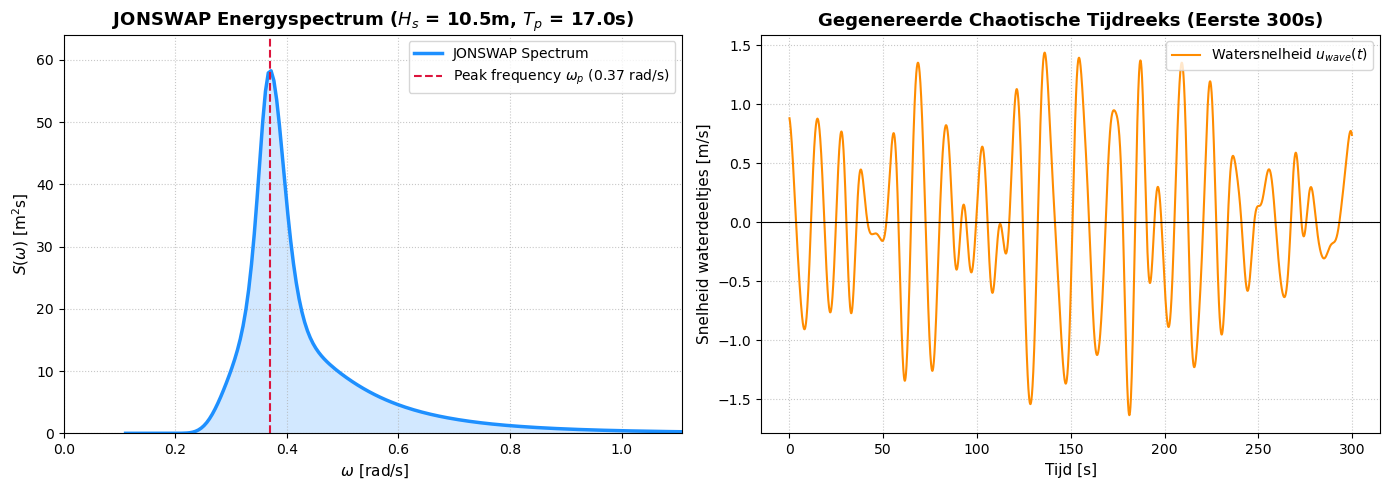

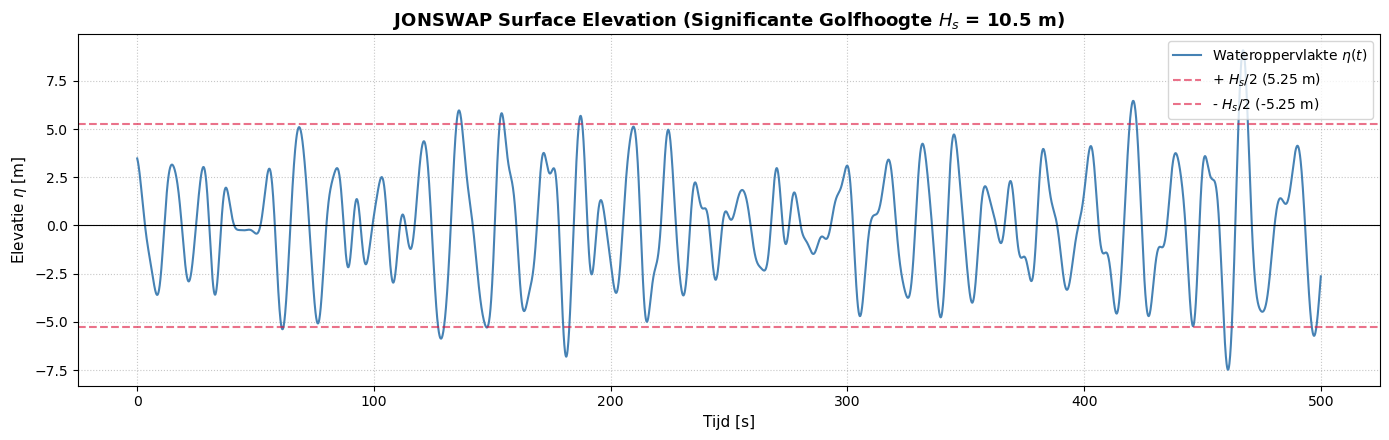

Berekende Max crest (golfkop): 9.09 m
Berekende Max trough (golfdal): -7.49 m


In [58]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as scpi
from scipy.interpolate import interp1d


rho_w = 1025.0       
U = 1.44             
H_s = 10.50          
T_p = 17.0           
z_axis = 25.0        
D_out = 20.0         
dist_c2c = 30.0      
C_d = 0.75           
C_m_coef = 2.0       
h = 54.0             
zeta = 0.05    

g = 9.81
t_sim = 1000.0                     
t_eval = np.arange(500, t_sim, 0.1)

C_s = 1.0 - 2.0 * 0.95 * np.sqrt((C_d * D_out) / (dist_c2c + 6.0 * D_out))


omega_p = (2 * np.pi) / T_p
gamma = 3.3  

N_freq = 200
omega = np.linspace(0.3 * omega_p, 3.0 * omega_p, N_freq)
d_omega = omega[1] - omega[0]

sigma = np.where(omega <= omega_p, 0.07, 0.09)
A = np.exp(-1.25 * (omega_p / omega)**4)
B = np.exp(-0.5 * ((omega - omega_p) / (sigma * omega_p))**2)
S_unscaled = (g**2 / omega**5) * A * (gamma**B)

m0_unscaled = np.trapezoid(S_unscaled, omega)
schaalfactor = (H_s / 4)**2 / m0_unscaled
S_omega = S_unscaled * schaalfactor

a_i = np.sqrt(2 * S_omega * d_omega)
np.random.seed(42)  
fase_i = np.random.uniform(0, 2 * np.pi, N_freq)
k_i = (omega**2) / g

# =========================================================
# 2B. JONSWAP SPECTRUM & KINEMATICA BEREKENEN EN PLOTTEN
# =========================================================

# 1. Zorg dat we de lege arrays klaarzetten
t_pre = np.linspace(0, t_sim + 10, int((t_sim + 10) * 10)) 
u_wave_pre = np.zeros_like(t_pre)
a_wave_pre = np.zeros_like(t_pre)

# 2. De loop (Let op de inspringing!)
for i in range(N_freq):
    fase_t = omega[i] * t_pre + fase_i[i]
    verval_factor = np.exp(-k_i[i] * z_axis)
    
    # Tel alle 200 sinusgolven bij elkaar op
    u_wave_pre += a_i[i] * omega[i] * verval_factor * np.cos(fase_t)
    a_wave_pre -= a_i[i] * (omega[i]**2) * verval_factor * np.sin(fase_t)

# 3. Maken van de plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Het Energiespectrum ---
ax1.plot(omega, S_omega, color='dodgerblue', linewidth=2.5, label='JONSWAP Spectrum')
ax1.axvline(omega_p, color='crimson', linestyle='--', label=f'Peak frequency $\omega_p$ ({omega_p:.2f} rad/s)')
ax1.fill_between(omega, 0, S_omega, color='dodgerblue', alpha=0.2)

ax1.set_title(f"JONSWAP Energyspectrum ($H_s$ = {H_s}m, $T_p$ = {T_p}s)", fontsize=13, fontweight='bold')
# FIX voor de waarschuwing: r voor de aanhalingstekens
ax1.set_xlabel(r" $\omega$ [rad/s]", fontsize=11)
ax1.set_ylabel(r"$S(\omega)$ [m$^2$s]", fontsize=11)
ax1.set_xlim(0, max(omega))
ax1.set_ylim(0, max(S_omega) * 1.1)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

# --- Plot 2: De gegenereerde onregelmatige stroomsnelheid ---
# Masker om expliciet in te zoomen op de eerste 300 seconden
mask = t_pre <= 300
ax2.plot(t_pre[mask], u_wave_pre[mask], color='darkorange', linewidth=1.5, label='Watersnelheid $u_{wave}(t)$')

ax2.set_title("Gegenereerde Chaotische Tijdreeks (Eerste 300s)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Tijd [s]", fontsize=11)
ax2.set_ylabel("Snelheid waterdeeltjes [m/s]", fontsize=11)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()
# =========================================================
# 2C. SURFACE ELEVATION (WATEROPPERVLAK) BEREKENEN & PLOTTEN
# =========================================================

# 1. Bereken de oppervlakte-elevatie (eta)
eta_pre = np.zeros_like(t_pre)

for i in range(N_freq):
    fase_t = omega[i] * t_pre + fase_i[i]
    # eta = a * cos(wt + phi). (Let op: hier zit géén e^(-kz) verval in, want we zijn op het oppervlak!)
    eta_pre += a_i[i] * np.cos(fase_t)

# 2. Plot de Surface Elevation
plt.figure(figsize=(14, 4.5))

# Plot een wat langere reeks (bijv. 500 seconden) om Wave Grouping te zien
mask_eta = t_pre <= 500

# Gebruik 'steelblue' voor een mooie water-kleur
plt.plot(t_pre[mask_eta], eta_pre[mask_eta], color='steelblue', linewidth=1.5, label='Wateroppervlakte $\eta(t)$')

# Voeg lijnen toe voor de Significante Golfhoogte (Hs/2)
plt.axhline(H_s / 2, color='crimson', linestyle='--', alpha=0.6, label=f'+ $H_s/2$ ({H_s/2} m)')
plt.axhline(-H_s / 2, color='crimson', linestyle='--', alpha=0.6, label=f'- $H_s/2$ ({-H_s/2} m)')

# Opmaak
plt.title(f"JONSWAP Surface Elevation (Significante Golfhoogte $H_s$ = {H_s} m)", fontsize=13, fontweight='bold')
plt.xlabel("Tijd [s]", fontsize=11)
plt.ylabel("Elevatie $\eta$ [m]", fontsize=11)
plt.axhline(0, color='black', linewidth=0.8) # Mean Water Level (MWL)
plt.grid(True, linestyle=':', alpha=0.7)

# Legenda netjes plaatsen
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

# Extra controle-print voor in je verslag:
print(f"Berekende Max crest (golfkop): {np.max(eta_pre[mask_eta]):.2f} m")
print(f"Berekende Max trough (golfdal): {np.min(eta_pre[mask_eta]):.2f} m")

u_wave_interp = interp1d(t_pre, u_wave_pre, kind='cubic')
a_wave_interp = interp1d(t_pre, a_wave_pre, kind='cubic')


In [61]:
# =========================================================
# BUILD Y_MASKER FOR FORCING
# =========================================================
Y_masker = np.zeros(len(DofsF))
for idx, dof in enumerate(DofsF):
    if dof % LDOF == 1:  # Y-direction only
        Y_masker[idx] = 1.0 if dof < (nDof // 2) else C_s

# =========================================================
# PHASE 1: USE MODES FROM A GIVEN INDEX RANGE OR LIST TO FIND STEADY-STATE RESPONSE
# =========================================================
print("Phase 1: Running with a limited set of modes to analyze response...")
# Provide either an explicit list/array of modes or a start/end range.
# Examples:
# mode_selection_input = [1001, 2000]         # inclusive limits
# mode_selection_input = np.arange(1001, 2001)  # explicit indices
 # aanpassen tussen duizendtallen
len(PHI_all)

Phase 1: Running with a limited set of modes to analyze response...


9552

In [66]:
for i in range(8):
    mode_selection_input = [1000 * i, 1000 * i + 999]  # Loop over blocks of 1000 modes
    # ensure we have valid 0-based indices within the range
    mode_selection = np.arange(mode_selection_input[0], mode_selection_input[1] + 1)
    mode_selection = mode_selection[(mode_selection >= 0) & (mode_selection < len(f))]
    if mode_selection.size == 0:
        raise ValueError("No valid modes selected. Check mode_selection_input and available mode count.")


    nMode_all = len(mode_selection)
    PHI_all = vr[:, mode_selection]
    f_all = f[mode_selection]
    M_FF_np = np.array(M_FF)

    # Modal parameters for the limited mode set
    Mm_all = np.zeros(nMode_all)
    Km_all = np.zeros(nMode_all)
    Cm_all = np.zeros(nMode_all)

    for i in range(nMode_all):
        omega_i = 2 * np.pi * f_all[i]
        Mm_all[i] = np.dot(PHI_all[:, i].T, np.dot(M_FF_np, PHI_all[:, i]))
        Km_all[i] = (omega_i**2) * Mm_all[i]
        Cm_all[i] = 2 * zeta * omega_i * Mm_all[i]

    # --- Spatial sampling to reduce array sizes: sample every K nodes (user-configurable)
    sample_node_step = 5
    node_sample_indices = np.arange(0, nNode, sample_node_step)
    # Y DOF number per node = node_index * LDOF + 1 (0-based dof numbering: 0=x,1=y,2=z,...)
    dof_numbers_sample = node_sample_indices * LDOF + 1

    # Find which of these DOF numbers are present in the free-DOF array (DofsF)
    mask_in_DofsF = np.in1d(DofsF, dof_numbers_sample)
    sampled_rows = np.where(mask_in_DofsF)[0]

    if sampled_rows.size == 0:
        # fallback: use every Y-DOF in DofsF (but still spaced by sample_node_step in nodes)
        sampled_rows = np.where(np.array([d % LDOF == 1 for d in DofsF]))[0]

    PHI_all_sample = PHI_all[sampled_rows, :]
    Y_masker_sample = Y_masker[sampled_rows]



    def P_modaal_all(t, Vm_i):
        u_wave_t = u_wave_interp(t) 
        a_wave_t = -a_wave_interp(t) 
        V = PHI_all_sample @ Vm_i
        u_totaal = U + u_wave_t - V
        F_drag = 0.5 * rho_w * C_d * D_out * u_totaal * np.abs(u_totaal)
        F_inertia = rho_w * C_m_coef * (np.pi * (D_out**2) / 4) * a_wave_t
        F_fysiek_sample = (F_drag + F_inertia) * h * Y_masker_sample
        # Project sampled physical forces into modal space (small matrix multiply)
        return PHI_all_sample.T @ F_fysiek_sample

    def qdot_all(t, q):
        Um_all = q[0:nMode_all]
        Vm_all = q[nMode_all:2*nMode_all]
        Am_all = (P_modaal_all(t, Vm_all) - (Km_all * Um_all + Cm_all * Vm_all)) / Mm_all
        return np.append(Vm_all, Am_all)

    q0_all = np.zeros(2 * nMode_all)
    t_sim = 30.0
    t_eval = np.arange(0, t_sim, 0.01)  # TIME INTERVAL, CONFERGENCE TEST?

    print(f"Running full integration with {nMode_all} modes over {t_sim} seconds...")
    sol_all = scpi.solve_ivp(fun=qdot_all, y0=q0_all, t_span=[0, t_sim], 
                            t_eval=t_eval, method='Radau')
    if not sol_all.success:
        print(f"Solver failed: {sol_all.message}")
    else:
        print("Phase 1 complete. Analyzing modal contributions in steady state...")
        
        # Extract steady-state window (last 15 seconds)
        t_steady_start = 15.0
        idx_steady = np.where(sol_all.t >= t_steady_start)[0]

        # Calculate modal displacement energy for each mode using only sampled spatial DOFs
        modal_energy = np.zeros(nMode_all)
        Um_all = sol_all.y[:nMode_all, :]

        if PHI_all_sample.shape[0] > 0 and idx_steady.size > 0:
            for i in range(nMode_all):
                phi_i = PHI_all_sample[:, i]            # shape: (n_sampled_dofs,)
                Um_i = Um_all[i, idx_steady]           # shape: (nt_steady,)
                # contribution at sampled DOFs over steady time window
                vals = (phi_i[:, None] * Um_i[None, :])**2
                modal_energy[i] = np.mean(vals)
        else:
            # fallback: use modal coordinate energy (cheap)
            for i in range(nMode_all):
                modal_energy[i] = np.mean(Um_all[i, idx_steady]**2)

        # Rank modes by energy
        mode_ranking = np.argsort(modal_energy)[::-1]

        # Select modes above threshold (or top 20 minimum)
        threshold_energy = 0.0000001
        selected_modes = mode_ranking[modal_energy[mode_ranking] > threshold_energy]
        if len(selected_modes) < 20:
            selected_modes = mode_ranking[:20]

        top_modes_idx = selected_modes
        nMode = len(top_modes_idx)
        
        print(f"\n✓ Selected {nMode} modes based on steady-state displacement energy")
        print(f"\nTop 15 modes (sorted by displacement participation):")
        for i in range(min(15, len(top_modes_idx))):
            mode_idx = top_modes_idx[i]
            energy = modal_energy[mode_idx]
            print(f"  Mode {mode_idx + mode_selection_input[0]}: f = {f_all[mode_idx]:.3f} Hz, Energy² = {energy:.6e}")
            # =========================================================
        # PHASE 2: SETUP FOR RE-RUN WITH SELECTED MODES
        # =========================================================
        PHI = vr[:, top_modes_idx]
        f_top = f[top_modes_idx]
        # Modal parameters for selected modes
        Mm = np.zeros(nMode)
        Km = np.zeros(nMode)
        Cm = np.zeros(nMode)
        
        for i in range(nMode):
            omega_i = 2 * np.pi * f_top[i]
            Mm[i] = np.dot(PHI[:, i].T, np.dot(M_FF_np, PHI[:, i]))
            Km[i] = (omega_i**2) * Mm[i]
            Cm[i] = 2 * zeta * omega_i * Mm[i]

            Km[i] = (omega_i**2) * Mm[i]
            Cm[i] = 2 * zeta * omega_i * Mm[i]
    #Indien opslaan gekozen modal shapes in een CSV bestand

    import pandas as pd

    df = pd.DataFrame({
        "mode": [int(top_modes_idx[i]+ mode_selection_input[0]) for i in range(len(top_modes_idx))],
        "energy": [float(modal_energy[top_modes_idx[i]]) for i in range(len(top_modes_idx))]
    })

    df.to_csv(f"modal_energy_{mode_selection_input[0]}-{mode_selection_input[-1]}.csv", index=False)

    df



C:\Users\boris\AppData\Local\Temp\ipykernel_22908\2016116518.py:33: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  mask_in_DofsF = np.in1d(DofsF, dof_numbers_sample)


Running full integration with 1000 modes over 30.0 seconds...
Phase 1 complete. Analyzing modal contributions in steady state...

✓ Selected 65 modes based on steady-state displacement energy

Top 15 modes (sorted by displacement participation):
  Mode 840: f = 0.015 Hz, Energy² = 6.460151e-01
  Mode 836: f = 0.015 Hz, Energy² = 3.252837e-01
  Mode 718: f = 0.013 Hz, Energy² = 1.031060e-01
  Mode 851: f = 0.016 Hz, Energy² = 3.644201e-02
  Mode 789: f = 0.014 Hz, Energy² = 2.947417e-02
  Mode 880: f = 0.016 Hz, Energy² = 1.233444e-02
  Mode 812: f = 0.015 Hz, Energy² = 1.044365e-02
  Mode 826: f = 0.015 Hz, Energy² = 1.036589e-02
  Mode 747: f = 0.014 Hz, Energy² = 7.968332e-03
  Mode 918: f = 0.017 Hz, Energy² = 6.848837e-03
  Mode 803: f = 0.015 Hz, Energy² = 5.172872e-03
  Mode 199: f = 0.003 Hz, Energy² = 4.987754e-03
  Mode 204: f = 0.004 Hz, Energy² = 3.480689e-03
  Mode 269: f = 0.005 Hz, Energy² = 2.908724e-03
  Mode 963: f = 0.018 Hz, Energy² = 2.771711e-03
Running full integr

In [ ]:
#Indien opslaan gekozen modal shapes in een CSV bestand

# import pandas as pd

# df = pd.DataFrame({
#     "mode": [int(top_modes_idx[i]+ mode_selection_input[0]) for i in range(len(top_modes_idx))],
#     "energy": [float(modal_energy[top_modes_idx[i]]) for i in range(len(top_modes_idx))]
# })

# df.to_csv("modal_energy_8002-9450.csv", index=False)

 df

In [ ]:
gekozen_modes_idx = [864, 715, 857, 766, 1701, 740, 749, 1705, 760, 880, 777, 869, 800, 850, 818, 1865, 829, 1698, 204, 1709, 1816, 823, 207, 1714, 1859, 1938, 274, 1813] #AANPASSEN!!!

nMode = len(gekozen_modes_idx)
print(f"--- START SOLVER MET {nMode} GEKOZEN MODES ---")

PHI = vr[:, gekozen_modes_idx]
f_gekozen = f[gekozen_modes_idx]
M_FF_np = np.array(M_FF)

Mm = np.zeros(nMode)
Km = np.zeros(nMode)
Cm = np.zeros(nMode)

for i in range(nMode):
    omega_i = 2 * np.pi * f_gekozen[i]
    print(f"  > Mode {gekozen_modes_idx[i]}: Freq = {f_gekozen[i]:.3f} Hz ingeladen.")
    Mm[i] = np.dot(PHI[:, i].T, np.dot(M_FF_np, PHI[:, i]))
    Km[i] = (omega_i**2) * Mm[i]
    Cm[i] = 2 * zeta * omega_i * Mm[i]


ruimtelijke_kracht_verdeling = np.zeros(len(DofsF))
for idx, dof in enumerate(DofsF):
    if dof % LDOF == 1: 
        ruimtelijke_kracht_verdeling[idx] = 1.0 if dof < (nDof // 2) else C_s

def P_modaal(t, Vm):
    u_wave_t = u_wave_interp(t)
    a_wave_t = a_wave_interp(t)
    
    V_fysiek = PHI @ Vm 
    
    u_rel = (U + u_wave_t) - V_fysiek
    
    F_drag = 0.5 * rho_w * C_d * D_out * u_rel * np.abs(u_rel)
    F_inertia = rho_w * C_m_coef * (np.pi * (D_out**2) / 4) * a_wave_t
    
    F_fysiek = (F_drag + F_inertia) * h * ruimtelijke_kracht_verdeling
    
    return PHI.T @ F_fysiek

def qdot(t, q):
    Um = q[0:nMode]          
    Vm = q[nMode:2*nMode]    
    Am = (P_modaal(t, Vm) - (Km * Um + Cm * Vm)) / Mm
    return np.append(Vm, Am)

q0 = np.zeros(2 * nMode)          

sol = scpi.solve_ivp(fun=qdot, y0=q0, t_span=[0, t_sim], t_eval=t_eval, method='Radau', rtol=1e-4, atol=1e-6)


--- START SOLVER MET 28 GEKOZEN MODES ---
  > Mode 864: Freq = 0.016 Hz ingeladen.
  > Mode 715: Freq = 0.013 Hz ingeladen.
  > Mode 857: Freq = 0.016 Hz ingeladen.
  > Mode 766: Freq = 0.014 Hz ingeladen.
  > Mode 1701: Freq = 0.049 Hz ingeladen.
  > Mode 740: Freq = 0.013 Hz ingeladen.
  > Mode 749: Freq = 0.014 Hz ingeladen.
  > Mode 1705: Freq = 0.050 Hz ingeladen.
  > Mode 760: Freq = 0.014 Hz ingeladen.
  > Mode 880: Freq = 0.016 Hz ingeladen.
  > Mode 777: Freq = 0.014 Hz ingeladen.
  > Mode 869: Freq = 0.016 Hz ingeladen.
  > Mode 800: Freq = 0.015 Hz ingeladen.
  > Mode 850: Freq = 0.016 Hz ingeladen.
  > Mode 818: Freq = 0.015 Hz ingeladen.
  > Mode 1865: Freq = 0.128 Hz ingeladen.
  > Mode 829: Freq = 0.015 Hz ingeladen.
  > Mode 1698: Freq = 0.048 Hz ingeladen.
  > Mode 204: Freq = 0.004 Hz ingeladen.
  > Mode 1709: Freq = 0.052 Hz ingeladen.
  > Mode 1816: Freq = 0.111 Hz ingeladen.
  > Mode 823: Freq = 0.015 Hz ingeladen.
  > Mode 207: Freq = 0.004 Hz ingeladen.
  > Mode 

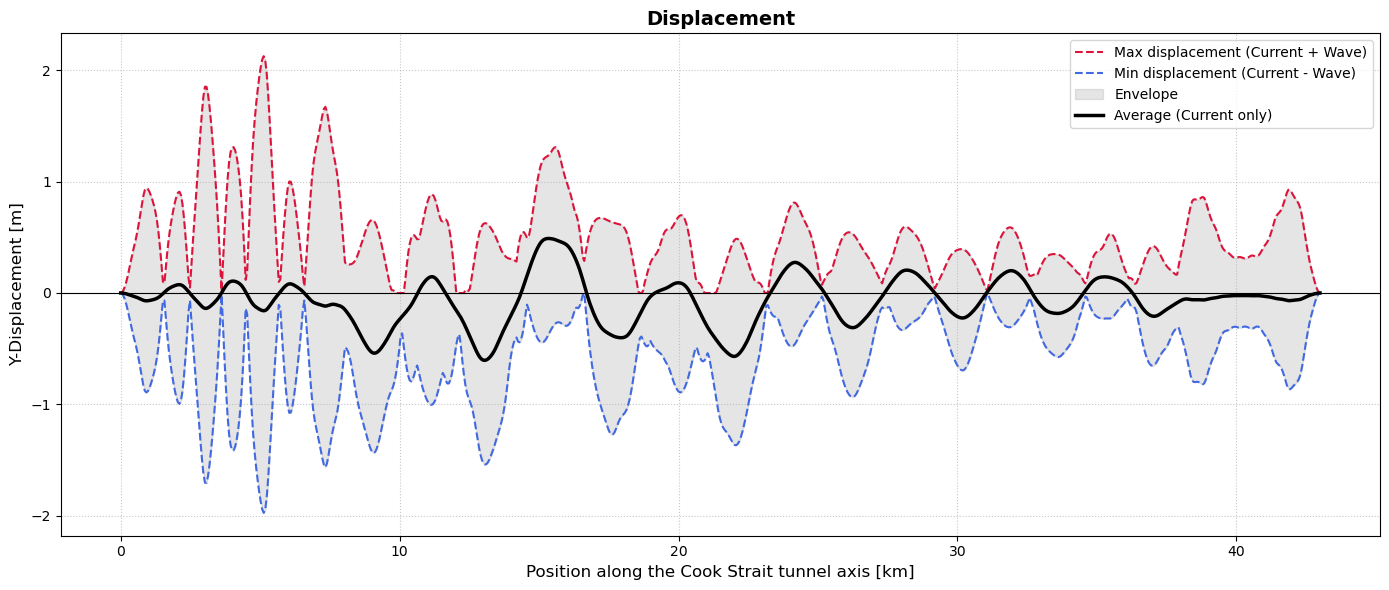

--- ANALYSE GEHELE TUNNEL (Koker 1) ---
Grootste absolute uitslag ergens op de tunnel: 2.13 m


In [ ]:
# =========================================================
# 5. RESULTATEN PLOTTEN (GEHELE TUNNEL - ENVELOPE)
# =========================================================
if sol.success:
    # 1. Terug naar fysieke domein voor de VRIJE DOFs
    U_F = (PHI @ sol.y[:nMode, :]).T  # Shape: (tijdstappen, aantal vrije dofs)

    # 2. Bouw de volledige verplaatsingsmatrix op (inclusief vaste steunpunten op de kust)
    # Dit is belangrijk, anders sluit je plot aan het uiteinde niet netjes aan op 0 meter.
    U_volledig = np.zeros((len(sol.t), nDof))
    U_volledig[:, DofsF] = U_F

    # 3. Filter alleen de Y-richting (index 1 per node) voor ALLE nodes in de tijd
    U_y_alle_nodes = U_volledig[:, 1::LDOF]

    # 4. Splits voor Koker 1 (we nemen aan dat de eerste helft van de nodes Koker 1 is)
    n_nodes_koker1 = U_y_alle_nodes.shape[1] // 2
    U_y_koker1 = U_y_alle_nodes[:, :n_nodes_koker1]

    # 5. Bereken de omhullende (envelope) over de tijd voor elke node
    # We pakken over de as '0' (de tijdas) de uiterste waarden per node
    max_uitslag_tunnel = np.max(U_y_koker1, axis=0)  # Maximale buiging (Stroom + Golfpiek)
    min_uitslag_tunnel = np.min(U_y_koker1, axis=0)  # Minimale buiging (Stroom - Golfdal)
    gemiddelde_buiging = np.mean(U_y_koker1, axis=0) # Statische uitslag (Alleen Stroom)

    # X-as voor de plot (0 tot totale lengte tunnel, we gaan uit van ~43 km)
    # Let op: pas 43.0 aan als jouw exacte tunnel_lengte iets anders is.
    x_as_km = np.linspace(0, 43.0, n_nodes_koker1)

    # 6. Plot de Envelope van de gehele tunnel
    plt.figure(figsize=(14, 6))
    
    # Plot de grenzen van de trilling
    plt.plot(x_as_km, max_uitslag_tunnel, color='crimson', linestyle='--', linewidth=1.5, label='Max displacement (Current + Wave)')
    plt.plot(x_as_km, min_uitslag_tunnel, color='royalblue', linestyle='--', linewidth=1.5, label='Min displacement (Current - Wave)')
    
    # Vul het gebied daartussenin (dit is het dynamisch trillingsbereik!)
    plt.fill_between(x_as_km, min_uitslag_tunnel, max_uitslag_tunnel, color='gray', alpha=0.2, label='Envelope')
    
    # Plot de statische gemiddelde buiging als dikke hoofdlijn
    plt.plot(x_as_km, gemiddelde_buiging, color='black', linewidth=2.5, label='Average (Current only)', zorder=5)

    plt.title("Displacement", fontsize=14, fontweight='bold')
    plt.xlabel("Position along the Cook Strait tunnel axis [km]", fontsize=12)
    plt.ylabel("Y-Displacement [m]", fontsize=12)
    plt.axhline(0, color='black', linewidth=0.8) # Reference line at 0 meter
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    # --- Extra analyse ---
    print("--- ANALYSE GEHELE TUNNEL (Koker 1) ---")
    absolute_max = np.max(np.abs(max_uitslag_tunnel))
    print(f"Grootste absolute uitslag ergens op de tunnel: {absolute_max:.2f} m")
else:
    print("Solver is vastgelopen:", sol.message)


Bezig met het reconstrueren van de versnellingen over de gehele tunnel...


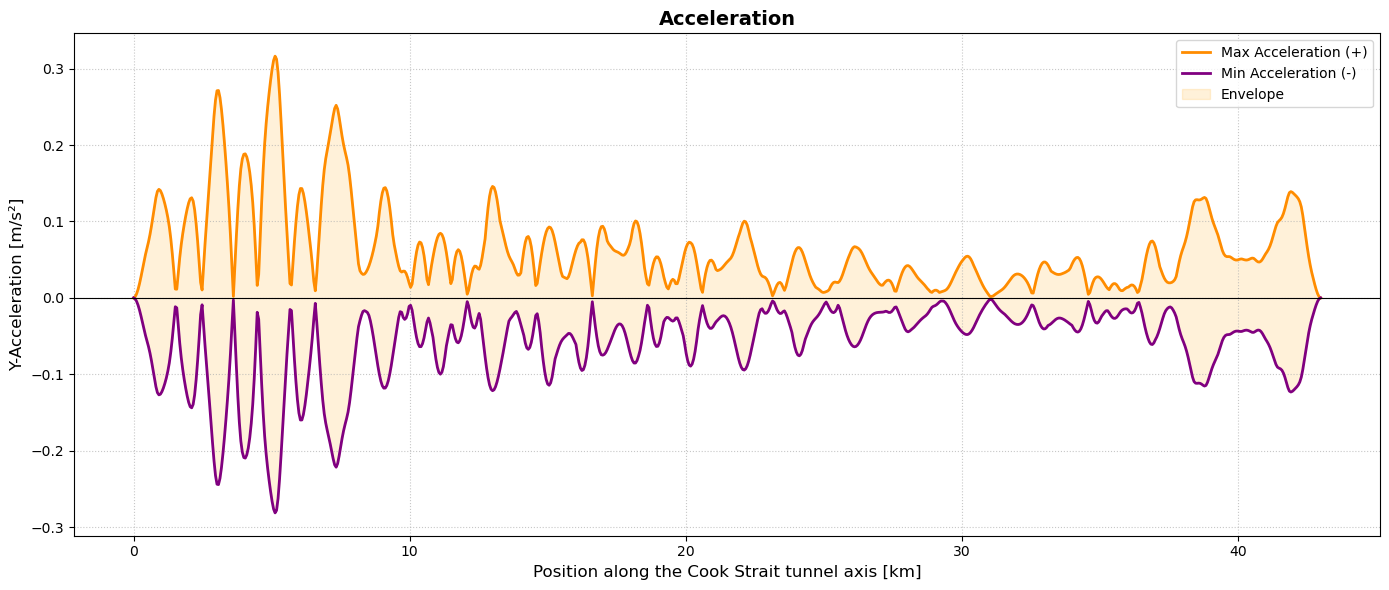

--- VERSNELLINGSANALYSE (Koker 1) ---
Grootste absolute versnelling: 0.3162 m/s²
Deze piek treedt op rond kilometer: 5.1 km
-> Versnelling is acceptabel voor gebruik.


In [ ]:
# =========================================================
# 6. RESULTATEN PLOTTEN (VERSNELLING - ENVELOPE GEHELE TUNNEL)
# =========================================================
print("\nBezig met het reconstrueren van de versnellingen over de gehele tunnel...")

if sol.success:
    # 1. Modale versnellingen (Am) berekenen voor ALLE tijdstappen
    # We maken een lege matrix aan met de vorm (aantal modes, aantal tijdstappen)
    Am_totaal = np.zeros((nMode, len(sol.t)))

    for i, t_i in enumerate(sol.t):
        Um_i = sol.y[0:nMode, i]
        Vm_i = sol.y[nMode:2*nMode, i]
        # Gebruik M*a + C*v + K*u = P om 'a' (modale versnelling) vrij te maken
        Am_totaal[:, i] = (P_modaal(t_i, Vm_i) - (Km * Um_i + Cm * Vm_i)) / Mm

    # 2. Terug naar fysieke domein (A = PHI * Am)
    A_F = (PHI @ Am_totaal).T  # Shape: (tijdstappen, aantal vrije dofs)

    # 3. Bouw de volledige versnellingsmatrix op (inclusief vaste kust-steunpunten = 0 m/s²)
    A_volledig = np.zeros((len(sol.t), nDof))
    A_volledig[:, DofsF] = A_F

    # 4. Filter de Y-richting (transversaal) en pak Koker 1
    A_y_alle_nodes = A_volledig[:, 1::LDOF]
    A_y_koker1 = A_y_alle_nodes[:, :n_nodes_koker1]

    # 5. Bereken de omhullende (envelope) voor de versnelling
    max_acc_tunnel = np.max(A_y_koker1, axis=0)  # Max positieve versnelling
    min_acc_tunnel = np.min(A_y_koker1, axis=0)  # Max negatieve versnelling

    # 6. Plot de Envelope van de versnelling
    plt.figure(figsize=(14, 6))
    
    plt.plot(x_as_km, max_acc_tunnel, color='darkorange', linestyle='-', linewidth=2, label='Max Acceleration (+)')
    plt.plot(x_as_km, min_acc_tunnel, color='purple', linestyle='-', linewidth=2, label='Min Acceleration (-)')
    
    # Vul het dynamische versnellingsbereik
    plt.fill_between(x_as_km, min_acc_tunnel, max_acc_tunnel, color='orange', alpha=0.15, label='Envelope')
    
    plt.title("Acceleration", fontsize=14, fontweight='bold')
    plt.xlabel("Position along the Cook Strait tunnel axis [km]", fontsize=12)
    plt.ylabel("Y-Acceleration [m/s²]", fontsize=12)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    # --- Extra analyse ---
    absolute_max_acc = np.max(np.abs(max_acc_tunnel))
    
    # Zoek uit op welke kilometer deze maximale versnelling optreedt
    node_met_max_acc = np.argmax(np.abs(max_acc_tunnel))
    km_max_acc = x_as_km[node_met_max_acc]
    
    print("--- VERSNELLINGSANALYSE (Koker 1) ---")
    print(f"Grootste absolute versnelling: {absolute_max_acc:.4f} m/s²")
    print(f"Deze piek treedt op rond kilometer: {km_max_acc:.1f} km")
    
    # Ter referentie voor je rapport (comfortgrens en constructiegrens)
    if absolute_max_acc > 1.0:
        print("-> LET OP: Versnelling > 1.0 m/s²! Dit is zeer hoog voor het comfort van treinpassagiers/auto's.")
    else:
        print("-> Versnelling is acceptabel voor gebruik.")

--- KRITISCHE KNOOP GEVONDEN ---
Node nummer: 95
Locatie op de tunnel: 5.13 km vanaf de kust


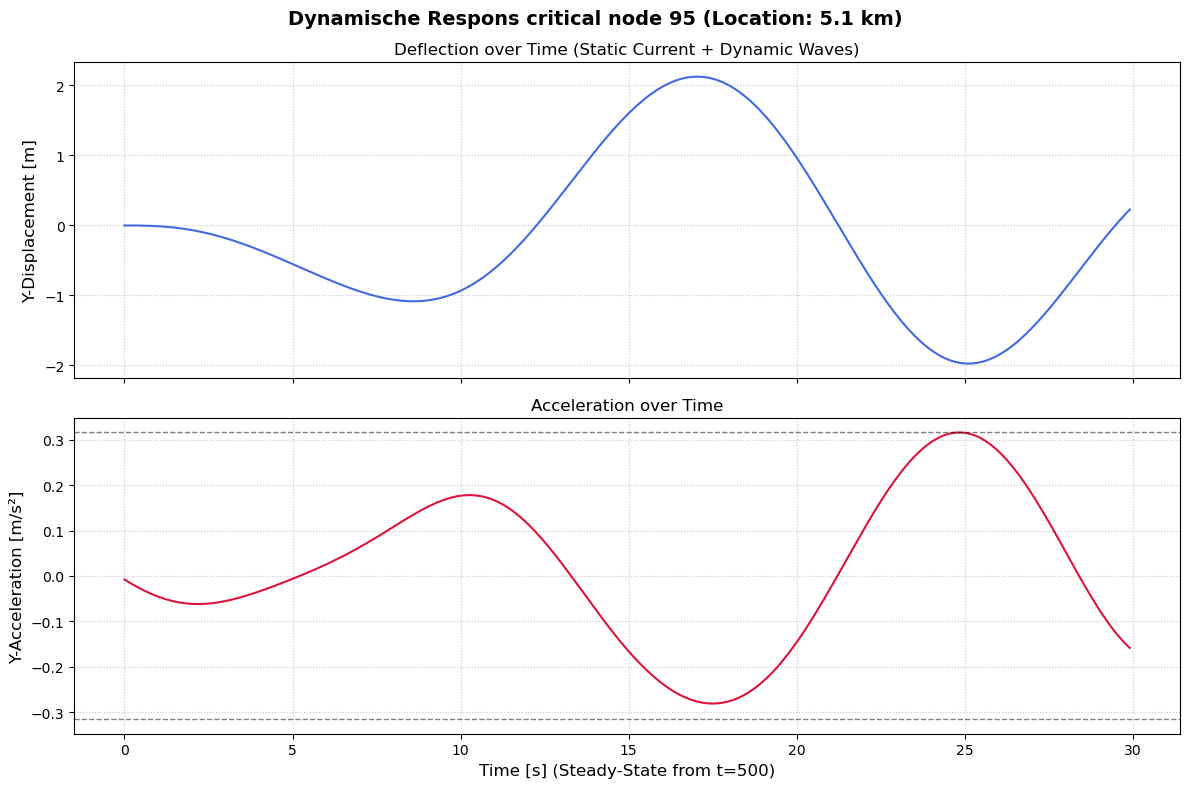


Data voor Node 95:
- Maximale Y-uitslag:   2.13 m
- Minimale Y-uitslag:   -1.97 m
- Maximale versnelling: 0.3162 m/s²


In [ ]:
# =========================================================
# 7. TIJDSDOMEIN PLOT VAN DE MEEST KRITISCHE KNOOP
# =========================================================

# De index in de Koker 1 array komt exact overeen met het Node-nummer
kritische_knoop = node_met_max_acc 
locatie_km = x_as_km[kritische_knoop]

print(f"--- KRITISCHE KNOOP GEVONDEN ---")
print(f"Node nummer: {kritische_knoop}")
print(f"Locatie op de tunnel: {locatie_km:.2f} km vanaf de kust")

# Haal de tijdreeksen op voor exact deze knoop uit de opgeslagen matrices
U_kritisch = U_y_koker1[:, kritische_knoop]
A_kritisch = A_y_koker1[:, kritische_knoop]

# =========================================================
# PLOTTEN VAN VERPLAATSING EN VERSNELLING
# =========================================================
# We maken een plot met 2 subplots onder elkaar die dezelfde X-as (tijd) delen
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

fig.suptitle(f"Dynamische Respons critical node {kritische_knoop} (Location: {locatie_km:.1f} km)", fontsize=14, fontweight='bold')

# Bovenste plot: Verplaatsing
ax1.plot(sol.t, U_kritisch, color='royalblue', linewidth=1.5)
ax1.set_ylabel("Y-Displacement [m]", fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.set_title("Deflection over Time (Static Current + Dynamic Waves)", fontsize=12)

# Onderste plot: Versnelling
ax2.plot(sol.t, A_kritisch, color='crimson', linewidth=1.5)
ax2.set_xlabel("Time [s] (Steady-State from t=500)", fontsize=12)
ax2.set_ylabel("Y-Acceleration [m/s²]", fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.set_title("Acceleration over Time", fontsize=12)

# Voeg maximale waarden toe als stippellijnen in de onderste plot voor extra duidelijkheid
max_acc = np.max(np.abs(A_kritisch))
ax2.axhline(max_acc, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.axhline(-max_acc, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

# Print nog even de harde data voor die knoop
print(f"\nData voor Node {kritische_knoop}:")
print(f"- Maximale Y-uitslag:   {np.max(U_kritisch):.2f} m")
print(f"- Minimale Y-uitslag:   {np.min(U_kritisch):.2f} m")
print(f"- Maximale versnelling: {max_acc:.4f} m/s²")

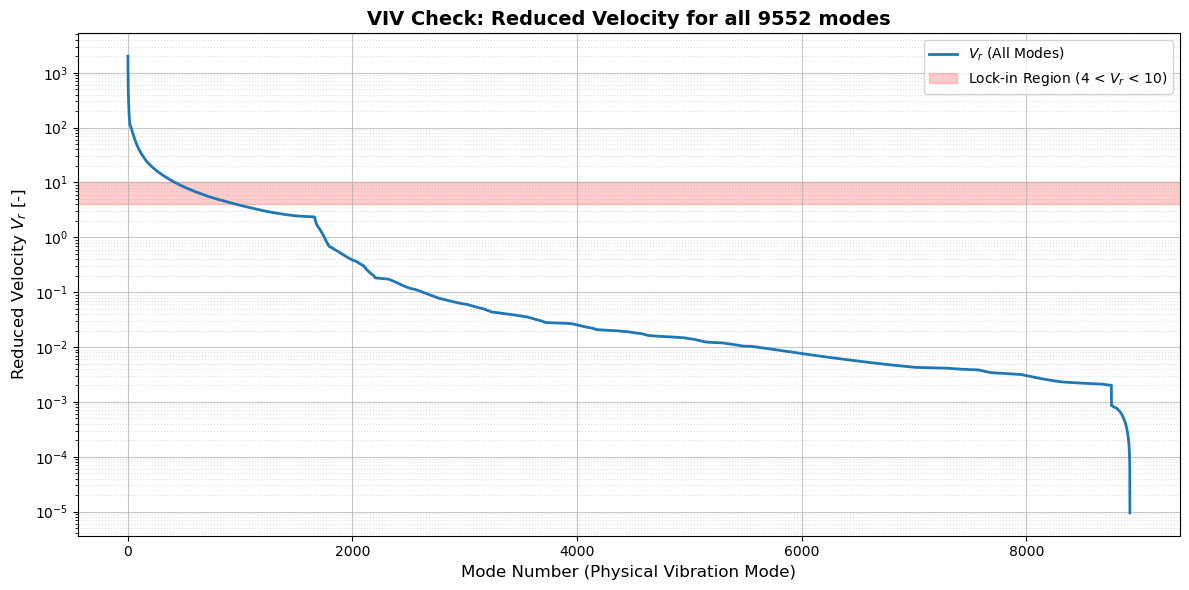

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# VIV CHECK: REDUCED VELOCITY TUNNEL VOOR ALLE MODES
# =========================================================
U_current = 1.44      # Stroomsnelheid [m/s]
D_buiten = 20.0       # Buitendiameter tunnel [m]

# Het totaal aantal modes is simpelweg de lengte van je frequentie-array 'f'
n_modes_totaal = len(f)

# We maken een array voor de X-as (Mode 1 t/m totale aantal modes)
modes_x = np.arange(1, n_modes_totaal + 1)

# Bereken de Reduced Velocity direct voor ALLE modes
Vr_plot = U_current / (f * D_buiten)

# =========================================================
# PLOTTEN (Met Logaritmische Y-as)
# =========================================================
plt.figure(figsize=(12, 6))

# Geen puntjes ('marker' weggehaald) en een doorgetrokken lijn (linestyle='-')
plt.semilogy(modes_x, Vr_plot, color='tab:blue', linestyle='-', linewidth=2.0, label='$V_r$ (All Modes)')

# De rode Lock-in gevarenzone (Vr tussen 4 en 10)
plt.axhspan(4.0, 10.0, color='red', alpha=0.2, label='Lock-in Region (4 < $V_r$ < 10)')

# Labels en titel
plt.title(f"VIV Check: Reduced Velocity for all {n_modes_totaal} modes", fontsize=14, fontweight='bold')
plt.xlabel("Mode Number (Physical Vibration Mode)", fontsize=12)
plt.ylabel("Reduced Velocity $V_r$ [-]", fontsize=12)

# Rasterlijnen toevoegen (Zowel grote als kleine stapjes voor de log-schaal)
plt.grid(True, which='major', linestyle='-', alpha=0.7)
plt.grid(True, which='minor', linestyle=':', alpha=0.4)

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Start VIV Check voor Samengestelde Ankerlijnen (Equivalente Kabel Methode)...



C:\Users\boris\AppData\Local\Temp\ipykernel_22908\3229283584.py:66: RuntimeWarning: divide by zero encountered in divide
  Vr_chain = U_stroom / (f_kabel * D_chain)


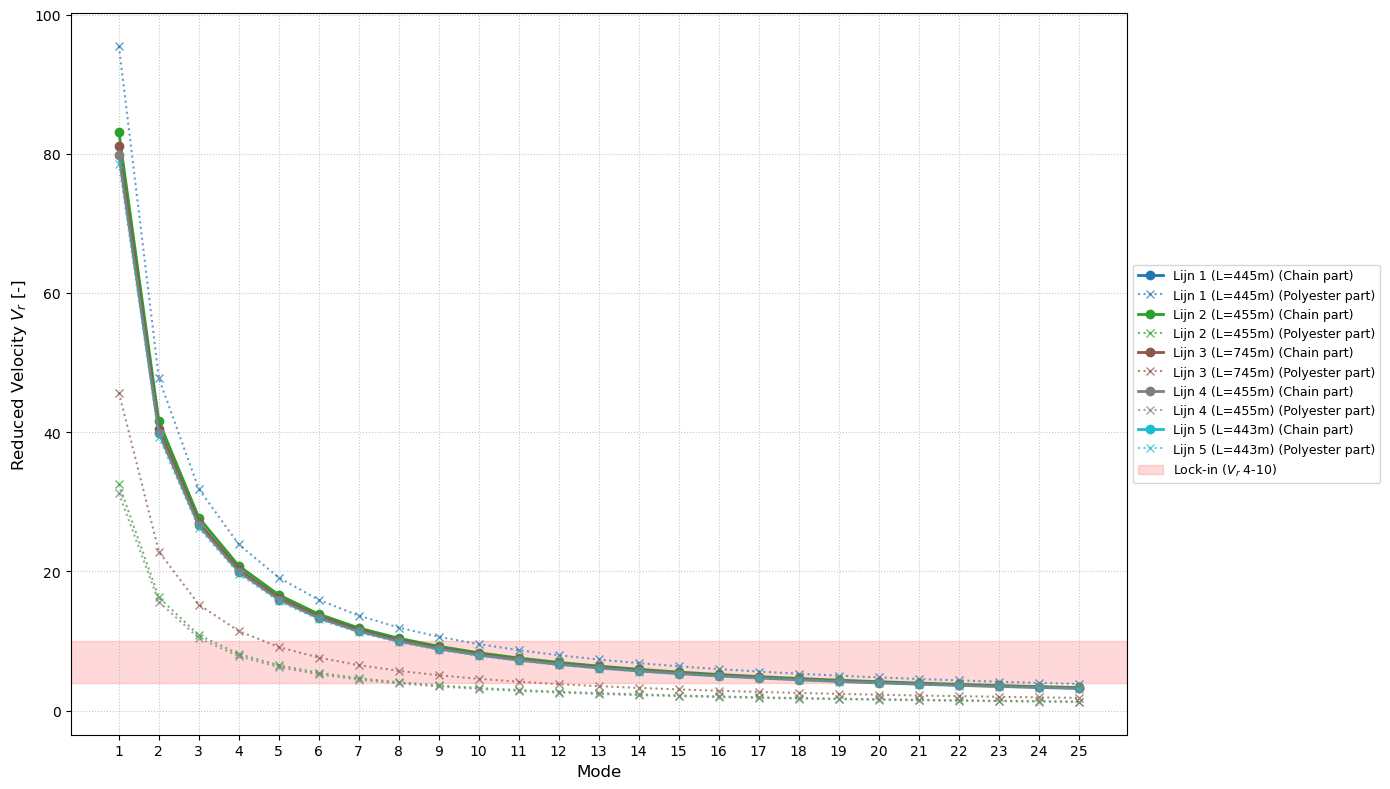

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. PARAMETERS VOOR COMPOSIET KABELS
# =========================================================
print("Start VIV Check voor Samengestelde Ankerlijnen (Equivalente Kabel Methode)...\n")

U_stroom = 1.44          # Watersnelheid [m/s]
rho_w = 1025.0           # Dichtheid water [kg/m3]
rho_staal = 7850.0       # Dichtheid staal (ketting) [kg/m3]
rho_poly = 1380.0        # Dichtheid polyester touw [kg/m3] (Typische offshore waarde)

# Gecombineerde data uit Table 10 (Lengtes) & Table 12 (Spanning & Diameters)
# L_chain = Bottom chain + Top chain
mooring_data = [
    {"naam": "Lijn 1 (L=445m)", "L_chain": 0,   "L_poly": 1002,  "L_tot": 1002, "T_max_kN": 1724,  "D_chain_mm": 0, "D_poly_mm": 112},
    {"naam": "Lijn 2 (L=455m)", "L_chain": 300+77,  "L_poly": 75, "L_tot": 455, "T_max_kN": 1939, "D_chain_mm": 54, "D_poly_mm": 138},
    {"naam": "Lijn 3 (L=745m)", "L_chain": 300+370, "L_poly": 75, "L_tot": 745, "T_max_kN": 4810, "D_chain_mm": 84, "D_poly_mm": 149},
    {"naam": "Lijn 4 (L=455m)", "L_chain": 360+20,  "L_poly": 75, "L_tot": 455, "T_max_kN": 2116, "D_chain_mm": 54, "D_poly_mm": 138},
    {"naam": "Lijn 5 (L=443m)", "L_chain": 0,   "L_poly": 1003,  "L_tot": 1003, "T_max_kN": 2550,  "D_chain_mm": 0, "D_poly_mm": 120}
]

n_kabel_modes = 25
modes = np.arange(1, n_kabel_modes + 1)
conclusies = []

# =========================================================
# 2. BEREKENING MET EQUIVALENTE MASSA
# =========================================================
plt.figure(figsize=(14, 8))
kleuren = plt.cm.tab10(np.linspace(0, 1, len(mooring_data)))

for i, data in enumerate(mooring_data):
    L_tot = data["L_tot"]
    T_kabel = data["T_max_kN"] * 1000.0  # kN naar Newton
    D_chain = data["D_chain_mm"] / 1000.0
    
    # Massa van de ketting secties
    A_chain = (np.pi / 4) * (D_chain**2)
    m_chain_dry = A_chain * rho_staal
    m_chain_added = rho_w * 1.0 * A_chain
    mu_chain = m_chain_dry + m_chain_added
    
    # Totale massa initiëren met de ketting
    M_totale_kabel = data["L_chain"] * mu_chain
    
    # Voeg het polyester gedeelte toe (indien aanwezig)
    if data["L_poly"] > 0:
        D_poly = data["D_poly_mm"] / 1000.0
        A_poly = (np.pi / 4) * (D_poly**2)
        m_poly_dry = A_poly * rho_poly
        m_poly_added = rho_w * 1.0 * A_poly
        mu_poly = m_poly_dry + m_poly_added
        
        M_totale_kabel += (data["L_poly"] * mu_poly)
        
    # --- EQUIVALENTE MASSA PER METER ---
    mu_eq = M_totale_kabel / L_tot
    
    # Globale Eigenfrequenties van de composiet kabel
    f_kabel = (modes / (2.0 * L_tot)) * np.sqrt(T_kabel / mu_eq)

    # LOKALE REDUCED VELOCITY BEREKENEN
    # 1. Voor het ketting-segment (Altijd aanwezig)
    Vr_chain = U_stroom / (f_kabel * D_chain)
    plt.plot(modes, Vr_chain, marker='o', color=kleuren[i], linewidth=2, linestyle='-', label=f'{data["naam"]} (Chain part)')
    
    # 2. Voor het polyester-segment (Indien aanwezig)
    if data["L_poly"] > 0:
        Vr_poly = U_stroom / (f_kabel * D_poly)
        plt.plot(modes, Vr_poly, marker='x', color=kleuren[i], linewidth=1.5, linestyle=':', alpha=0.7, label=f'{data["naam"]} (Polyester part)')

    # Opslaan voor output (we checken de gevaren op het dunste/gevaarlijkste stuk: de ketting)
    cf_modes = modes[(Vr_chain >= 4.0) & (Vr_chain <= 10.0)]
    conclusies.append({'Naam': data["naam"], 'f1': f_kabel[0], 'CF_risico_chain': list(cf_modes)})

# =========================================================
# 3. VIV GEVARENZONES PLOTTEN
# =========================================================
plt.axhspan(4.0, 10.0, color='red', alpha=0.15, label='Lock-in ($V_r$ 4-10)')

# plt.title("Lokaal VIV Risico voor Samengestelde Ankerlijnen (Ketting + Polyester)", fontsize=14, fontweight='bold')
plt.xlabel("Mode", fontsize=12)
plt.ylabel("Reduced Velocity $V_r$ [-]", fontsize=12)
plt.xticks(np.arange(1, n_kabel_modes + 1, step=1))
plt.grid(True, linestyle=':', alpha=0.7)

# Legenda buiten de grafiek plaatsen omdat het best veel lijnen zijn
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
plt.tight_layout()
plt.show()

